<a href="https://colab.research.google.com/github/notbuzzK/Thesis/blob/main/thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cells below are for downloading colab packages to drive**

optional but saves time in reinstalling it every runtime session.
note: takes a lot of space, else run "pip install ultralytics"

In [ ]:
import os
# Creates folder in Drive
package_path = '/content/drive/MyDrive/colab_packages'
os.makedirs(package_path, exist_ok=True)

In [ ]:
# Run this only once!
!pip install ultralytics ensemble-boxes thop --target='/content/drive/MyDrive/colab_packages'

In [ ]:
!pip install torchmetrics --target='/content/drive/MyDrive/colab_packages'

In [ ]:
!pip install roboflow pycocotools progress torchmetrics --target='/content/drive/MyDrive/colab_packages/'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
# Tell Python to look in your Drive folder first
sys.path.append('/content/drive/MyDrive/colab_packages')

# Now you can import immediately without installing
import ultralytics
from ensemble_boxes import weighted_boxes_fusion
from roboflow import Roboflow
print("✅ Libraries loaded from Drive!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries loaded from Drive!


# **Fixed OG 4 cells**

## **Cell 1: Setup**

In [ ]:
import os, sys, torch, torchvision
import torch.nn as nn
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from ultralytics import YOLO

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
TARGET_SIZE = 512

# ── MobileNetV3CenterNet definition ───────────────────────────────────────
class MobileNetV3CenterNet(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        mobilenet    = mobilenet_v3_large(
            weights=MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
        )
        self.backbone = mobilenet.features   # (B, 960, H/32, W/32)
        self.decoder  = nn.Sequential(
            nn.ConvTranspose2d(960, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
        )
        self.hm  = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, kernel_size=1),
        )
        self.wh  = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 2, kernel_size=1),
        )
        self.reg = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 2, kernel_size=1),
        )
        nn.init.constant_(self.hm[-1].bias, -2.19)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.decoder(feat)
        return [{'hm': self.hm(feat), 'wh': self.wh(feat), 'reg': self.reg(feat)}]

# ── Load models ────────────────────────────────────────────────────────────
yolo_model  = YOLO('yolov8m.pt').to(DEVICE).eval()
ssd_model   = ssdlite320_mobilenet_v3_large(weights='DEFAULT').to(DEVICE).eval()
center_model = MobileNetV3CenterNet(num_classes=80, pretrained=True).to(DEVICE).eval()
# Note: pretrained=True loads ImageNet MobileNetV3 backbone
# num_classes=80 for pretrained COCO-equivalent baseline
# (will be replaced to 5 during fine-tuning)

print(f"✅ All models loaded on {DEVICE} @ {TARGET_SIZE}px.")

✅ All models loaded on cuda @ 512px.


## **Cell 1.5: Load Fine Tuned Weights**

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 7 + 1  # 5 custom classes + background

# Save paths
YOLO_SAVE_DIR = "/content/drive/MyDrive/thesis/models/finetuned"
SSD_SAVE      = "/content/drive/MyDrive/thesis/models/finetuned/ssd_custom_v2.pth"
CENTER_SAVE   = "/content/drive/MyDrive/thesis/models/finetuned/centernet_custom.pth"

# ── YOLO ───────────────────────────────────────────────────────────────────────
from ultralytics import YOLO
yolo_model = YOLO(os.path.join(YOLO_SAVE_DIR, 'yolov8m_custom_v2/weights/best.pt')).to(DEVICE).eval()
print("✅ YOLOv8m fine-tuned weights loaded.")

# ── SSD — load with DEFAULT first to get correct backbone structure ─────────────
ssd_ft = ssdlite320_mobilenet_v3_large(weights='DEFAULT')  # correct backbone shape

in_channels = [672, 480, 512, 256, 256, 128]
num_anchors  = [6, 6, 6, 6, 6, 6]

ssd_ft.head.classification_head = SSDLiteClassificationHead(
    in_channels = in_channels,
    num_anchors = num_anchors,
    num_classes = NUM_CLASSES,
    norm_layer  = nn.BatchNorm2d,
)

# Now load your fine-tuned weights — backbone + new head should match
ssd_ft.load_state_dict(torch.load(SSD_SAVE))
ssd_ft = ssd_ft.to(DEVICE).eval()
print("✅ SSD fine-tuned weights loaded.")

# ── MobileNetV3CenterNet — new ─────────────────────────────────────────────
CENTER_SAVE_V4 = "/content/drive/MyDrive/thesis/models/finetuned/mobilenet_centernet_v4.pth"
center_ft = MobileNetV3CenterNet(num_classes=7, pretrained=False).to(DEVICE)
center_ft.load_state_dict(torch.load(CENTER_SAVE_V4))
center_ft.eval()
print("✅ MobileNetV3CenterNet fine-tuned loaded.")

✅ YOLOv8m fine-tuned weights loaded.
✅ SSD fine-tuned weights loaded.
✅ MobileNetV3CenterNet fine-tuned loaded.


In [ ]:
# Confirm which YOLO weights are actually loaded
print(f"YOLO model type: {type(yolo_model)}")
print(f"YOLO model path: {yolo_model.ckpt_path}")

# Also check what classes it knows
print(f"YOLO classes: {yolo_model.names}")
print(f"Number of classes: {len(yolo_model.names)}")

YOLO model type: <class 'ultralytics.models.yolo.model.YOLO'>
YOLO model path: yolov8m.pt
YOLO classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 't

In [ ]:
# Paste in a new cell
import os, cv2, torch

test_imgs = [os.path.join(custom_test_images, f)
             for f in os.listdir(custom_test_images)
             if f.endswith(('.jpg','.png'))][:3]

for path in test_imgs:
    boxes, scores, labels, latency = run_hybrid_inference(path)
    print(f"{os.path.basename(path)}: {len(boxes) if boxes else 0} detections, latency={latency:.4f}s")

# Also confirm center_ft is actually loaded
print(f"\ncenter_ft type: {type(center_ft)}")
print(f"center_ft device: {next(center_ft.parameters()).device}")
print(f"center_ft training mode: {center_ft.training}")

# Check hm head
dummy = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE).to(DEVICE)
with torch.no_grad():
    out = center_ft(dummy)[-1]
hm = torch.sigmoid(out['hm'])
print(f"hm max score: {hm.max().item():.4f}")
print(f"hm mean score: {hm.mean().item():.4f}")

sign-13-_mp4-0023_jpg.rf.fef3d7c2c3647ba62cb6b55872453066.jpg: 100 detections, latency=0.0101s
sign-1-_mp4-0020_jpg.rf.5f241f2badc49255459e8a6de510412a.jpg: 100 detections, latency=0.0088s
barrier-8-_mp4-0049_jpg.rf.a741d755e400d0637866d178dbe6abce.jpg: 100 detections, latency=0.0088s

center_ft type: <class '__main__.MobileNetV3CenterNet'>
center_ft device: cuda:0
center_ft training mode: False
hm max score: 0.0124
hm mean score: 0.0001


In [ ]:
# Reload v2 weights explicitly
CENTER_SAVE_V2 = "/content/drive/MyDrive/thesis/models/finetuned/mobilenet_centernet_v2.pth"

center_ft = MobileNetV3CenterNet(num_classes=5, pretrained=False).to(DEVICE)
center_ft.load_state_dict(torch.load(CENTER_SAVE_V2, map_location=DEVICE))
center_ft.eval()

# Verify
dummy = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE).to(DEVICE)
with torch.no_grad():
    out = center_ft(dummy)[-1]
hm = torch.sigmoid(out['hm'])
print(f"hm max score: {hm.max().item():.4f}")
print(f"hm mean score: {hm.mean().item():.4f}")

# Quick detection test
path = test_imgs[0]
boxes, scores, labels, latency = run_hybrid_inference(path)
print(f"Detections: {len(boxes)}  scores: {[round(s,2) for s in scores[:5]]}")

hm max score: 0.0095
hm mean score: 0.0001
Detections: 100  scores: [0.11, 0.11, 0.11, 0.11, 0.11]


In [ ]:
import os
finetuned_dir = "/content/drive/MyDrive/thesis/models/finetuned"
for f in os.listdir(finetuned_dir):
    size = os.path.getsize(os.path.join(finetuned_dir, f))
    print(f"{f}: {size/1e6:.2f} MB")

yolov8m_custom: 0.00 MB
ssd_custom.pth: 9.36 MB
centernet_custom.pth: 63.36 MB
mobilenet_centernet_v2.pth: 30.68 MB
mobilenet_centernet_v3.pth: 30.68 MB
yolov8s_custom: 0.00 MB


## **Cell 2: Paths**

In [ ]:
import os, json

# ── DRIVE PATHS (you uploaded both versions here) ──────────────────────────────
CUSTOM_YOLO_DIR = "/content/drive/MyDrive/thesis/datasets/yolov8_v2"
CUSTOM_COCO_DIR = "/content/drive/MyDrive/thesis/datasets/coco-json_v2"

# YOLOv8 format paths
custom_yaml_path   = os.path.join(CUSTOM_YOLO_DIR, "data.yaml")
custom_test_images = os.path.join(CUSTOM_YOLO_DIR, "test", "images")

# COCO JSON paths — images are co-located with the annotation file
custom_coco_json   = os.path.join(CUSTOM_COCO_DIR, "test", "_annotations.coco.json")
custom_coco_images = os.path.join(CUSTOM_COCO_DIR, "test")   # images sit in same folder

# DORIE paths (adjust if your DORIE folder structure differs)
DORIE_YOLO_YAML  = "/content/drive/MyDrive/thesis/datasets/DORIE/dorie_eval.yaml"
DORIE_IMG_DIR    = "/content/drive/MyDrive/thesis/datasets/DORIE/images/test"
DORIE_COCO_JSON  = "/content/drive/MyDrive/thesis/datasets/DORIE/test/_annotations.coco.json"
DORIE_COCO_IMGS  = "/content/drive/MyDrive/thesis/datasets/DORIE/test"

# ── FIX DUPLICATE/MISALIGNED COCO CATEGORY IDs ────────────────────────────────
# Roboflow exported 6 categories with foldout-signs duplicated at id=0 and id=2
# Correct mapping based on data.yaml:
# 0=barriers, 1=foldout-signs, 2=poles, 3=railings, 4=signs

CORRECT_CATEGORIES = [
    {'id': 1, 'name': 'barriers',      'supercategory': 'obstacle'},
    {'id': 2, 'name': 'curbs',         'supercategory': 'obstacle'},
    {'id': 3, 'name': 'foldout-signs', 'supercategory': 'obstacle'},
    {'id': 4, 'name': 'poles',         'supercategory': 'obstacle'},
    {'id': 5, 'name': 'potholes',      'supercategory': 'obstacle'},
    {'id': 6, 'name': 'railings',      'supercategory': 'obstacle'},
    {'id': 7, 'name': 'signs',         'supercategory': 'obstacle'},
]

# ── SANITY CHECK ───────────────────────────────────────────────────────────────
print("Checking paths...")
for label, path in [
    ("Custom YAML",       custom_yaml_path),
    ("Custom test imgs",  custom_test_images),
    ("Custom COCO JSON",  custom_coco_json),
    ("DORIE YAML",        DORIE_YOLO_YAML),
    ("DORIE test imgs",   DORIE_IMG_DIR),
    ("DORIE COCO JSON",   DORIE_COCO_JSON),
]:
    exists = os.path.exists(path)
    print(f"  {'✅' if exists else '❌'} {label}: {path}")

# ── VERIFY COCO CATEGORY IDs ───────────────────────────────────────────────────
print("\nCustom COCO categories:")
with open(custom_coco_json) as f:
    ann = json.load(f)
for cat in ann['categories']:
    print(f"  id={cat['id']}  name={cat['name']}")

# Build a remapping from the broken Roboflow IDs → correct 1-indexed IDs
# Based on what the verify block printed:
# id=0 foldout-signs, id=1 barriers, id=2 foldout-signs, id=3 poles,
# id=4 railings, id=5 signs
ROBOFLOW_ID_REMAP = {
    0: 3,   # foldout-signs (duplicate at 0) → 3
    1: 1,   # barriers                       → 1
    2: 2,   # curbs                          → 2
    3: 3,   # foldout-signs                  → 3
    4: 4,   # poles                          → 4
    5: 5,   # pothole → potholes             → 5
    6: 6,   # railings                       → 6
    7: 7,   # signs                          → 7
}

# Apply remap to all annotations
fixed_annotations = []
for a in ann['annotations']:
    fixed_a = dict(a)
    old_id  = a['category_id']
    fixed_a['category_id'] = ROBOFLOW_ID_REMAP.get(old_id, old_id)
    fixed_annotations.append(fixed_a)

# Write fixed JSON back to Drive
ann_fixed = {
    'info':        ann.get('info', {}),
    'licenses':    ann.get('licenses', []),
    'categories':  CORRECT_CATEGORIES,
    'images':      ann['images'],
    'annotations': fixed_annotations,
}

fixed_json_path = os.path.join(CUSTOM_COCO_DIR, "test", "_annotations_fixed.coco.json")
with open(fixed_json_path, 'w') as f:
    json.dump(ann_fixed, f)

# Point custom_coco_json to the fixed version from here on
custom_coco_json = fixed_json_path

print("\nFixed COCO categories:")
for cat in CORRECT_CATEGORIES:
    print(f"  id={cat['id']}  name={cat['name']}")
print(f"✅ Fixed JSON saved → {fixed_json_path}")
print(f"   Annotations remapped: {len(fixed_annotations)} total")

# Verify no stray IDs remain
remaining_ids = set(a['category_id'] for a in fixed_annotations)
print(f"   Category IDs present in annotations: {sorted(remaining_ids)}")

Checking paths...
  ✅ Custom YAML: /content/drive/MyDrive/thesis/datasets/yolov8_v2/data.yaml
  ✅ Custom test imgs: /content/drive/MyDrive/thesis/datasets/yolov8_v2/test/images
  ✅ Custom COCO JSON: /content/drive/MyDrive/thesis/datasets/coco-json_v2/test/_annotations.coco.json
  ✅ DORIE YAML: /content/drive/MyDrive/thesis/datasets/DORIE/dorie_eval.yaml
  ✅ DORIE test imgs: /content/drive/MyDrive/thesis/datasets/DORIE/images/test
  ✅ DORIE COCO JSON: /content/drive/MyDrive/thesis/datasets/DORIE/test/_annotations.coco.json

Custom COCO categories:
  id=0  name=foldout-signs
  id=1  name=barriers
  id=2  name=curbs
  id=3  name=foldout-signs
  id=4  name=poles
  id=5  name=pothole
  id=6  name=railings
  id=7  name=signs

Fixed COCO categories:
  id=1  name=barriers
  id=2  name=curbs
  id=3  name=foldout-signs
  id=4  name=poles
  id=5  name=potholes
  id=6  name=railings
  id=7  name=signs
✅ Fixed JSON saved → /content/drive/MyDrive/thesis/datasets/coco-json_v2/test/_annotations_fixed.

In [ ]:
# Run this standalone before setting ROBOFLOW_ID_REMAP
import json
with open(custom_coco_json) as f:
    ann = json.load(f)
print("Raw categories from new COCO JSON:")
for cat in ann['categories']:
    print(f"  id={cat['id']}  name={cat['name']}")

Raw categories from new COCO JSON:
  id=1  name=barriers
  id=2  name=curbs
  id=3  name=foldout-signs
  id=4  name=poles
  id=5  name=potholes
  id=6  name=railings
  id=7  name=signs


## **Cell 3: Hybrid Engine**

In [ ]:
dummy = torch.randn(1, 3, 512, 512).to(DEVICE)
with torch.no_grad():
    out = center_model(dummy)[-1]
print("hm shape:", out['hm'].shape)

hm shape: torch.Size([1, 80, 64, 64])


In [ ]:
import torch, cv2, time, numpy as np
from ensemble_boxes import weighted_boxes_fusion

# ── CenterNet decoder ──────────────────────────────────────────────────────────
def _nms(heat, kernel=3):
    """Simple max-pool NMS on heatmap."""
    pad = (kernel - 1) // 2
    hmax = torch.nn.functional.max_pool2d(heat, kernel, stride=1, padding=pad)
    return heat * (heat == hmax).float()

''' revert top_k = 100 post testing '''
def decode_centernet(output, target_size, conf_thresh=0.1, top_k=100):
    """
    Decode raw CenterNet output dict into normalized [x1,y1,x2,w2] boxes.
    output: dict with keys 'hm', 'wh', 'reg'  (shapes: B x C x H x W)
    Returns: boxes (N,4), scores (N,), labels (N,) — all numpy, boxes normalized 0-1
    """
    hm  = torch.sigmoid(output['hm'])   # (1, 80, H, W)
    wh  = output['wh']                  # (1, 2, H, W)
    reg = output['reg']                 # (1, 2, H, W)

    hm  = _nms(hm)
    B, C, H, W = hm.shape

    # Flatten and get top-k
    hm_flat = hm.view(B, -1)                          # (1, C*H*W)
    scores_all, inds = torch.topk(hm_flat[0], min(top_k, hm_flat.shape[1]))
    mask = scores_all > conf_thresh
    scores_all = scores_all[mask]
    inds = inds[mask]
    if len(inds) == 0:
        return np.zeros((0, 4)), np.array([]), np.array([])

    clses = (inds // (H * W)).cpu().numpy().astype(int)
    ys    = ((inds % (H * W)) // W).cpu().numpy()
    xs    = ((inds % (H * W)) % W).cpu().numpy()

    # Offsets and sizes
    reg_np = reg[0].cpu().numpy()  # (2, H, W)
    wh_np  = wh[0].cpu().numpy()   # (2, H, W)

    cx = (xs + reg_np[0, ys, xs]) / W   # normalized center x
    cy = (ys + reg_np[1, ys, xs]) / H   # normalized center y
    bw = wh_np[0, ys, xs] / target_size
    bh = wh_np[1, ys, xs] / target_size

    x1 = np.clip(cx - bw / 2, 0, 1)
    y1 = np.clip(cy - bh / 2, 0, 1)
    x2 = np.clip(cx + bw / 2, 0, 1)
    y2 = np.clip(cy + bh / 2, 0, 1)

    boxes  = np.stack([x1, y1, x2, y2], axis=1)
    scores = scores_all.cpu().numpy()
    return boxes, scores, clses

# ── Hybrid inference ───────────────────────────────────────────────────────────
def run_hybrid_inference(img_path, conf_thresh=0.1):
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, 0

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_tensor  = (torch.from_numpy(img_resized / 255.)
                       .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    torch.cuda.synchronize()
    t1 = time.time()

    """ REMEBER TO CHANGE MODEL WEIGHTS HERE """
    """ ssd_model/center_model ssd_ft/center_ft """
    with torch.no_grad():
        out_ssd    = ssd_ft(img_tensor)[0]
        out_center = center_ft(img_tensor)[-1]   # last decoder head

    torch.cuda.synchronize()
    latency = time.time() - t1

    # ── SSD: normalize boxes to [0,1]
    boxes_ssd  = (out_ssd['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
    scores_ssd = out_ssd['scores'].cpu().numpy().tolist()
    labels_ssd = (out_ssd['labels'].cpu().numpy() - 1).tolist()  # SSD is 1-indexed

    # ── CenterNet: proper decode (THIS WAS THE MAIN BUG)
    boxes_cen, scores_cen, labels_cen = decode_centernet(out_center, TARGET_SIZE, conf_thresh)
    boxes_cen  = boxes_cen.tolist()
    scores_cen = scores_cen.tolist()
    labels_cen = labels_cen.tolist()

    # ── WBF fusion (CenterNet weight=2 per thesis p.43)
    if not boxes_ssd and not boxes_cen:
        return [], [], [], latency

    boxes, scores, labels = weighted_boxes_fusion(
        [boxes_ssd,  boxes_cen],
        [scores_ssd, scores_cen],
        [labels_ssd, labels_cen],
        weights=[1, 2],
        iou_thr=0.45,
        skip_box_thr=conf_thresh,
    )
    return boxes.tolist(), scores.tolist(), labels.tolist(), latency

print("✅ Fixed Hybrid Engine loaded (CenterNet properly decoded).")

✅ Fixed Hybrid Engine loaded (CenterNet properly decoded).


In [ ]:
def run_hybrid_inference_tta(img_path, conf_thresh=0.1):
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, 0

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))

    # ── Create two augmented versions ─────────────────────────────────────
    # View 1: original
    img1 = img_resized
    # View 2: horizontal flip
    img2 = cv2.flip(img_resized, 1)

    def to_tensor(im):
        return (torch.from_numpy(im / 255.)
                    .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    torch.cuda.synchronize()
    t1 = time.time()

    with torch.no_grad():
        # SSD on original
        out_ssd1 = ssd_ft(to_tensor(img1))[0]
        # MobileNetV3CenterNet on original + flipped
        out_cn1  = center_ft(to_tensor(img1))[-1]
        out_cn2  = center_ft(to_tensor(img2))[-1]

    torch.cuda.synchronize()
    latency = time.time() - t1

    # ── SSD detections ─────────────────────────────────────────────────────
    boxes_ssd  = (out_ssd1['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
    scores_ssd = out_ssd1['scores'].cpu().numpy().tolist()
    labels_ssd = (out_ssd1['labels'].cpu().numpy() - 1).tolist()

    # ── CenterNet view 1 ───────────────────────────────────────────────────
    boxes_cn1, scores_cn1, labels_cn1 = decode_centernet(
        out_cn1, TARGET_SIZE, conf_thresh)
    boxes_cn1  = boxes_cn1.tolist()
    scores_cn1 = scores_cn1.tolist()
    labels_cn1 = labels_cn1.tolist()

    # ── CenterNet view 2 (flip) — mirror boxes back ────────────────────────
    boxes_cn2_raw, scores_cn2, labels_cn2 = decode_centernet(
        out_cn2, TARGET_SIZE, conf_thresh)
    # Mirror x-coordinates: x1_new = 1 - x2_old, x2_new = 1 - x1_old
    boxes_cn2 = []
    for box in boxes_cn2_raw:
        x1, y1, x2, y2 = box
        boxes_cn2.append([1 - x2, y1, 1 - x1, y2])
    scores_cn2 = scores_cn2.tolist()
    labels_cn2 = labels_cn2.tolist()

    if not boxes_ssd and not boxes_cn1 and not boxes_cn2:
        return [], [], [], latency

    # ── WBF across all three prediction sets ──────────────────────────────
    # SSD weight=1, CenterNet original weight=2, CenterNet flipped weight=1
    all_boxes  = [b for b in [boxes_ssd, boxes_cn1, boxes_cn2] if b]
    all_scores = [s for s in [scores_ssd, scores_cn1, scores_cn2]
                  if s is not None and len(s) > 0]
    all_labels = [l for l in [labels_ssd, labels_cn1, labels_cn2]
                  if l is not None and len(l) > 0]
    weights    = [w for b, w in zip(
                  [boxes_ssd, boxes_cn1, boxes_cn2], [1, 2, 1]) if b]

    boxes, scores, labels = weighted_boxes_fusion(
        all_boxes, all_scores, all_labels,
        weights=weights,
        iou_thr=0.45,
        skip_box_thr=conf_thresh,
    )
    return boxes.tolist(), scores.tolist(), labels.tolist(), latency

In [ ]:
import torch, cv2, time, numpy as np
from ensemble_boxes import weighted_boxes_fusion

# ── CenterNet decoder ──────────────────────────────────────────────────────────
def _nms(heat, kernel=3):
    """Simple max-pool NMS on heatmap."""
    pad = (kernel - 1) // 2
    hmax = torch.nn.functional.max_pool2d(heat, kernel, stride=1, padding=pad)
    return heat * (heat == hmax).float()

''' revert top_k = 100 post testing '''
def decode_centernet(output, target_size, conf_thresh=0.1, top_k=100):
    """
    Decode raw CenterNet output dict into normalized [x1,y1,x2,w2] boxes.
    output: dict with keys 'hm', 'wh', 'reg'  (shapes: B x C x H x W)
    Returns: boxes (N,4), scores (N,), labels (N,) — all numpy, boxes normalized 0-1
    """
    hm  = torch.sigmoid(output['hm'])   # (1, 80, H, W)
    wh  = output['wh']                  # (1, 2, H, W)
    reg = output['reg']                 # (1, 2, H, W)

    hm  = _nms(hm)
    B, C, H, W = hm.shape

    # Flatten and get top-k
    hm_flat = hm.view(B, -1)                          # (1, C*H*W)
    scores_all, inds = torch.topk(hm_flat[0], min(top_k, hm_flat.shape[1]))
    mask = scores_all > conf_thresh
    scores_all = scores_all[mask]
    inds = inds[mask]
    if len(inds) == 0:
        return np.zeros((0, 4)), np.array([]), np.array([])

    clses = (inds // (H * W)).cpu().numpy().astype(int)
    ys    = ((inds % (H * W)) // W).cpu().numpy()
    xs    = ((inds % (H * W)) % W).cpu().numpy()

    # Offsets and sizes
    reg_np = reg[0].cpu().numpy()  # (2, H, W)
    wh_np  = wh[0].cpu().numpy()   # (2, H, W)

    cx = (xs + reg_np[0, ys, xs]) / W   # normalized center x
    cy = (ys + reg_np[1, ys, xs]) / H   # normalized center y
    bw = wh_np[0, ys, xs] / target_size
    bh = wh_np[1, ys, xs] / target_size

    x1 = np.clip(cx - bw / 2, 0, 1)
    y1 = np.clip(cy - bh / 2, 0, 1)
    x2 = np.clip(cx + bw / 2, 0, 1)
    y2 = np.clip(cy + bh / 2, 0, 1)

    boxes  = np.stack([x1, y1, x2, y2], axis=1)
    scores = scores_all.cpu().numpy()
    return boxes, scores, clses

def run_hybrid_inference(img_path, conf_thresh=0.1):
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, 0

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_tensor  = (torch.from_numpy(img_resized / 255.)
                       .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    torch.cuda.synchronize()
    t1 = time.time()

    with torch.no_grad():
        out_center = center_model(img_tensor)[-1]

    torch.cuda.synchronize()
    latency = time.time() - t1

    # ── CenterNet decode only
    boxes, scores, labels = decode_centernet(out_center, TARGET_SIZE, conf_thresh)

    if len(boxes) == 0:
        return [], [], [], latency

    return boxes.tolist(), scores.tolist(), labels.tolist(), latency

print("✅ Hybrid Engine loaded (MobileNetV3CenterNet fine-tuned, no WBF).")

✅ Hybrid Engine loaded (MobileNetV3CenterNet fine-tuned, no WBF).


In [ ]:
def run_hybrid_inference(img_path, conf_thresh=0.1):
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, 0

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_flipped = cv2.flip(img_resized, 1)

    def to_tensor(im):
        return (torch.from_numpy(im / 255.)
                    .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    torch.cuda.synchronize()
    t1 = time.time()

    with torch.no_grad():
        out_orig   = center_ft(to_tensor(img_resized))[-1]
        out_flip   = center_ft(to_tensor(img_flipped))[-1]

    torch.cuda.synchronize()
    latency = time.time() - t1

    # Decode original
    boxes_o, scores_o, labels_o = decode_centernet(out_orig, TARGET_SIZE, conf_thresh)

    # Decode flipped — mirror boxes back
    boxes_f, scores_f, labels_f = decode_centernet(out_flip, TARGET_SIZE, conf_thresh)
    if len(boxes_f) > 0:
        boxes_f[:, 0], boxes_f[:, 2] = 1 - boxes_f[:, 2].copy(), 1 - boxes_f[:, 0].copy()

    # Combine
    if len(boxes_o) == 0 and len(boxes_f) == 0:
        return [], [], [], latency

    boxes  = np.concatenate([boxes_o,  boxes_f],  axis=0) if len(boxes_o) > 0 and len(boxes_f) > 0 else (boxes_o if len(boxes_o) > 0 else boxes_f)
    scores = np.concatenate([scores_o, scores_f], axis=0) if len(scores_o) > 0 and len(scores_f) > 0 else (scores_o if len(scores_o) > 0 else scores_f)
    labels = np.concatenate([labels_o, labels_f], axis=0) if len(labels_o) > 0 and len(labels_f) > 0 else (labels_o if len(labels_o) > 0 else labels_f)

    return boxes.tolist(), scores.tolist(), labels.tolist(), latency

print("✅ Hybrid Engine loaded (MobileNetV3CenterNet + TTA).")

✅ Hybrid Engine loaded (MobileNetV3CenterNet + TTA).


In [ ]:
# Quick solo check with fixed decode
res_center_v2 = run_solo_eval(
    center_ft_model_fn, center_ft_decode_fn,
    custom_coco_images, coco_gt_custom,
    label="MobileNetV3CenterNet"
)
print(f"MobileNetV3CenterNet solo: mAP={res_center_v2['mAP50']}  FNR={res_center_v2['FNR']}")

Solo eval [MobileNetV3CenterNet]: 100%|██████████| 467/467 [00:08<00:00, 55.28it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.15s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.570
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.570
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.451
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.620
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.520
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.658
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.658
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

## **Cell 3.5: COCO JSON generation**

In [ ]:
import os, json, yaml
from PIL import Image

def yolo_labels_to_coco(images_dir, labels_dir, yaml_path, output_json_path):
    """
    Converts a YOLO-format dataset (images + .txt label files) into
    a COCO-format _annotations.coco.json file.
    """
    with open(yaml_path) as f:
        data = yaml.safe_load(f)
    class_names = data['names']
    # Handle both list and dict formats from YOLO yaml
    if isinstance(class_names, dict):
        class_names = [class_names[i] for i in sorted(class_names.keys())]

    categories = [{'id': i, 'name': name, 'supercategory': 'obstacle'}
                  for i, name in enumerate(class_names)]

    images_out      = []
    annotations_out = []
    ann_id          = 1

    img_files = sorted([
        f for f in os.listdir(images_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    for img_id, fname in enumerate(img_files):
        img_path = os.path.join(images_dir, fname)
        try:
            with Image.open(img_path) as im:
                w, h = im.size
        except Exception:
            print(f"  ⚠️  Could not open {fname}, skipping.")
            continue

        images_out.append({
            'id':        img_id,
            'file_name': fname,
            'width':     w,
            'height':    h,
        })

        # Match label file — same stem, .txt extension
        label_fname = os.path.splitext(fname)[0] + '.txt'
        label_path  = os.path.join(labels_dir, label_fname)

        if not os.path.exists(label_path):
            # Image with no annotations — still include in images list
            continue

        with open(label_path) as lf:
            for line in lf:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) != 5:
                    continue

                cls_id  = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])

                # Convert YOLO normalized xywh → COCO absolute xywh
                abs_w  = bw * w
                abs_h  = bh * h
                abs_x1 = (cx - bw / 2) * w
                abs_y1 = (cy - bh / 2) * h

                annotations_out.append({
                    'id':          ann_id,
                    'image_id':    img_id,
                    'category_id': cls_id,   # 0-indexed, matching your yaml
                    'bbox':        [abs_x1, abs_y1, abs_w, abs_h],
                    'area':        abs_w * abs_h,
                    'iscrowd':     0,
                })
                ann_id += 1

    coco_out = {
        'info':        {'description': 'DORIE test set converted from YOLO format'},
        'categories':  categories,
        'images':      images_out,
        'annotations': annotations_out,
    }

    os.makedirs(os.path.dirname(output_json_path), exist_ok=True)
    with open(output_json_path, 'w') as f:
        json.dump(coco_out, f)

    print(f"✅ Converted {len(images_out)} images, {ann_id - 1} annotations")
    print(f"   Saved → {output_json_path}")

# ── RUN CONVERSION ─────────────────────────────────────────────────────────────
# Point these at your actual test split, not val
DORIE_TEST_IMGS   = "/content/drive/MyDrive/thesis/datasets/DORIE/images/test"
DORIE_TEST_LABELS = "/content/drive/MyDrive/thesis/datasets/DORIE/labels/test"
DORIE_YAML_PATH   = "/content/drive/MyDrive/thesis/datasets/DORIE/dorie_eval.yaml"
DORIE_COCO_JSON   = "/content/drive/MyDrive/thesis/datasets/DORIE/test/_annotations.coco.json"

yolo_labels_to_coco(
    images_dir       = DORIE_TEST_IMGS,
    labels_dir       = DORIE_TEST_LABELS,
    yaml_path        = DORIE_YAML_PATH,
    output_json_path = DORIE_COCO_JSON,
)

✅ Converted 187 images, 1363 annotations
   Saved → /content/drive/MyDrive/thesis/datasets/DORIE/test/_annotations.coco.json


In [ ]:
DORIE_TEST_IMGS   = "/content/drive/MyDrive/thesis/datasets/DORIE/images/test"
DORIE_TEST_LABELS = "/content/drive/MyDrive/thesis/datasets/DORIE/labels/test"
DORIE_YAML_PATH   = "/content/drive/MyDrive/thesis/datasets/DORIE/dorie_eval.yaml"
DORIE_COCO_JSON   = "/content/drive/MyDrive/thesis/datasets/DORIE/test/_annotations.coco.json"

## **Cell 4: Full Inference**

In [ ]:
import os, json, time, numpy as np, pandas as pd
from tqdm import tqdm
from thop import profile
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ── 0. INSTALL IF NEEDED ───────────────────────────────────────────────────────
# !pip install pycocotools --quiet

# ══════════════════════════════════════════════════════════════════════════════
# 1. MACs
# ══════════════════════════════════════════════════════════════════════════════
def get_gmacs(model):
    m = model.model if hasattr(model, 'model') else model
    dummy = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE).to(DEVICE)
    macs, _ = profile(m, inputs=(dummy,), verbose=False)
    return round(macs / 1e9, 4)

gmacs_yolo   = get_gmacs(yolo_model)
'''
un comment line below for original setup, remove this comment
'''
# gmacs_hybrid = round(get_gmacs(ssd_ft) + get_gmacs(center_ft), 4)
gmacs_hybrid = get_gmacs(center_model)
print(f"MACs → YOLO: {gmacs_yolo} G  |  Hybrid: {gmacs_hybrid} G")

# ══════════════════════════════════════════════════════════════════════════════
# 2. CLASS BRIDGE  (thesis Table 4, p.58)
# Custom classes (0-indexed): 0=barriers, 1=foldout-signs, 2=poles, 3=railings, 4=signs
# COCO classes (0-indexed):   9=traffic_light, 10=fire_hydrant,
#                             11=stop_sign, 12=parking_meter, 13=bench
# ══════════════════════════════════════════════════════════════════════════════
# Updated bridge — target category_id is now 1-indexed to match fixed JSON
BRIDGE_COCO_TO_CUSTOM = {
    9:  4,   # traffic_light  → poles     (id=4)
    10: 4,   # fire_hydrant   → poles     (id=4)
    11: 7,   # stop_sign      → signs     (id=7)
    12: 7,   # parking_meter  → signs     (id=7)
    13: 1,   # bench          → barriers  (id=1)
}

BRIDGE_COCO_TO_DORIE = {
    9:  5,   # traffic_light  → Pole         (vertical structure)
    10: 0,   # fire_hydrant   → Bollard       (short vertical obstacle)
    11: 2,   # stop_sign      → Traffic Sign  (closest semantic match)
    12: 2,   # parking_meter  → Traffic Sign
    13: 3,   # bench          → Guardrail     (horizontal barrier)
}

# ══════════════════════════════════════════════════════════════════════════════
# 3. RIGOROUS FPS TIMING  (thesis methodology p.60)
# ══════════════════════════════════════════════════════════════════════════════
def measure_fps_rigorous(inference_fn, img_paths, warmup=5, timed_runs=30, repetitions=3):
    """
    5 warmup iters (discarded) → 30 timed iters w/ cuda.synchronize()
    → repeated 3 times independently → report mean FPS and std in ms.
    """
    # Build a fixed-length list by cycling through available images
    def make_list(n):
        return (img_paths * ((n // len(img_paths)) + 1))[:n]

    warmup_paths = make_list(warmup)
    timed_paths  = make_list(timed_runs)
    all_frame_times = []

    for rep in range(repetitions):
        # Warmup (discarded)
        for path in warmup_paths:
            inference_fn(path)

        # Timed runs
        rep_times = []
        for path in timed_paths:
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            inference_fn(path)
            torch.cuda.synchronize()
            rep_times.append(time.perf_counter() - t0)

        all_frame_times.extend(rep_times)

    mean_fps       = round(1 / np.mean(all_frame_times), 2)
    std_ms         = round(np.std(all_frame_times) * 1000, 2)
    return mean_fps, std_ms

# Collect image paths for timing
'''
custom_img_list = [
    os.path.join(custom_test_images, f)
    for f in os.listdir(custom_test_images)
    if f.lower().endswith(('.jpg', '.png'))
]
'''

import shutil
shutil.copytree(custom_test_images, '/content/test_images_local', dirs_exist_ok=True)

custom_img_list = [
    os.path.join('/content/test_images_local', f)
    for f in os.listdir('/content/test_images_local')
    if f.lower().endswith(('.jpg', '.png'))
]

def yolo_infer(path):
    yolo_model.predict(path, imgsz=TARGET_SIZE, verbose=False)

def hybrid_infer(path):
    run_hybrid_inference(path)

print("Measuring FPS (this takes ~2 min)...")
yolo_fps, yolo_fps_std = measure_fps_rigorous(
    yolo_infer, custom_img_list,
    warmup=15,       # increase from 5 to 15 for YOLO
    timed_runs=30,
    repetitions=3
)
hybrid_fps, hybrid_fps_std = measure_fps_rigorous(hybrid_infer, custom_img_list)
print(f"  YOLO   : {yolo_fps} FPS  (±{yolo_fps_std} ms/frame)")
print(f"  Hybrid : {hybrid_fps} FPS  (±{hybrid_fps_std} ms/frame)")

# ══════════════════════════════════════════════════════════════════════════════
# 4. YOLO VALIDATION  (both datasets)
# ══════════════════════════════════════════════════════════════════════════════
def run_yolo_val(yaml_path, split='test'):
    res = yolo_model.val(
        data=yaml_path, split=split, imgsz=TARGET_SIZE,
        batch=16, plots=False, verbose=False
    )
    return {
        'mAP50':     round(float(res.box.map50), 4),
        'FNR':       round(float(1 - res.box.mr), 4),
        # YOLO doesn't natively separate small-object FNR; flagged as N/A
        'FNR_small': 'N/A',
        'mAP50_small': 'N/A',
    }

print("\nRunning YOLO validation...")
yolo_custom = run_yolo_val(custom_yaml_path, split='test')
yolo_dorie  = run_yolo_val(DORIE_YOLO_YAML,  split='test')
print(f"  Custom → mAP50: {yolo_custom['mAP50']}  FNR: {yolo_custom['FNR']}")
print(f"  DORIE  → mAP50: {yolo_dorie['mAP50']}   FNR: {yolo_dorie['FNR']}")

# ══════════════════════════════════════════════════════════════════════════════
# 5. HYBRID VALIDATION via COCOeval  (proper IoU-matched FNR)
# ══════════════════════════════════════════════════════════════════════════════
def compute_fnr_from_cocoeval(coco_eval_obj):
    """Extract TP/FN from completed COCOeval at IoU=0.50."""
    tp, fn = 0, 0
    for ev in coco_eval_obj.evalImgs:
        if ev is None:
            continue
        gt_ignore  = ev['gtIgnore']
        dt_matches = ev['dtMatches']
        if len(dt_matches) == 0:
            valid_gt_count = sum(1 for ig in gt_ignore if not ig)
            fn += valid_gt_count
            continue
        matched_gt_ids = set(m for m in dt_matches[0] if m > 0)
        for idx, ig in enumerate(gt_ignore):
            if ig:
                continue
            gt_id = ev['gtIds'][idx]
            if gt_id in matched_gt_ids:
                tp += 1
            else:
                fn += 1
    return round(fn / (fn + tp), 4) if (fn + tp) > 0 else 1.0

def run_hybrid_val_coco(img_dir, coco_ann_path, bridge, label=""):
    """
    Runs hybrid inference on all images in img_dir,
    maps COCO labels → target labels via bridge,
    computes mAP@50 (overall + small) and FNR (overall + small) via COCOeval.
    Note: img_dir should be the folder that CONTAINS the images,
          which is the same folder as _annotations.coco.json in Roboflow's structure.
    """
    coco_gt  = COCO(coco_ann_path)
    img_ids  = coco_gt.getImgIds()
    results  = []

    actual_files = os.listdir(img_dir)
    file_lookup  = {f.lower(): f for f in actual_files}

    for img_id in tqdm(img_ids, desc=f"Hybrid inference [{label}]"):
        info     = coco_gt.loadImgs(img_id)[0]
        fname    = file_lookup.get(info['file_name'].lower())
        if fname is None:
            continue
        img_path = os.path.join(img_dir, fname)
        w_orig, h_orig = info['width'], info['height']

        boxes, scores, labels_out, _ = run_hybrid_inference(img_path)

        if boxes is None or len(boxes) == 0:
            continue

        for box, score, lbl in zip(boxes, scores, labels_out):
            lbl_int = int(round(lbl))
            if bridge is not None:
                if lbl_int not in bridge:
                    continue
                target_lbl = bridge[lbl_int]
            else:
                # Post fine-tuning: direct mapping
                # SSD outputs 1-indexed, CenterNet outputs 0-indexed
                # WBF averages them so labels may be fractional — round and clamp
                ''' remove comment below for original setup '''
                # target_lbl = max(1, min(5, lbl_int if lbl_int >= 1 else lbl_int + 1))
                target_lbl = lbl_int + 1  # center_ft is always 0-indexed (0-4) → COCO 1-indexed (1-5)
            x1, y1, x2, y2 = box
            results.append({
                'image_id':    img_id,
                'category_id': target_lbl,   # COCO is 1-indexed
                'bbox': [
                    x1 * w_orig,
                    y1 * h_orig,
                    (x2 - x1) * w_orig,
                    (y2 - y1) * h_orig,
                ],
                'score': float(score),
            })

    if not results:
        print(f"  ⚠️  No detections matched the class bridge for [{label}]. mAP will be 0.")
        return {'mAP50': 0.0, 'FNR': 1.0, 'mAP50_small': 0.0, 'FNR_small': 1.0}

    coco_dt = coco_gt.loadRes(results)

    # ── Overall mAP@50 and FNR ─────────────────────────────────────────────
    ce_all = COCOeval(coco_gt, coco_dt, 'bbox')
    ce_all.params.iouThrs = np.array([0.50])
    ce_all.evaluate(); ce_all.accumulate(); ce_all.summarize()
    map50_all = round(float(ce_all.stats[0]), 4)
    fnr_all   = compute_fnr_from_cocoeval(ce_all)

    # ── Small-object mAP@50 and FNR  (area < 32² px per COCO convention) ──
    ce_small = COCOeval(coco_gt, coco_dt, 'bbox')
    ce_small.params.iouThrs   = np.array([0.50])
    ce_small.params.areaRng   = [[0, 32 ** 2]]
    ce_small.params.areaRngLbl = ['small']
    ce_small.evaluate(); ce_small.accumulate(); ce_small.summarize()
    map50_small = round(float(ce_small.stats[0]), 4)
    # fnr_small   = compute_fnr_from_cocoeval(ce_small)
    # Replace the fnr_small line with:
    fnr_small = compute_fnr_from_cocoeval(ce_small)
    if fnr_small == 1.0 and ce_small.stats[0] == -1:
        fnr_small = 'N/A'
        map50_small = 'N/A'

    return {
        'mAP50':       map50_all,
        'FNR':         fnr_all,
        'mAP50_small': map50_small,
        'FNR_small':   fnr_small,
    }

print("\nRunning Hybrid validation...")

hybrid_custom = run_hybrid_val_coco(
    img_dir      = custom_coco_images,
    coco_ann_path= custom_coco_json,
    bridge       = BRIDGE_COCO_TO_CUSTOM,
    label        = "Custom"
)
hybrid_dorie = run_hybrid_val_coco(
    img_dir       = DORIE_TEST_IMGS,
    coco_ann_path = DORIE_COCO_JSON,
    bridge        = BRIDGE_COCO_TO_DORIE,
    label         = "DORIE"
)
'''
hybrid_custom = run_hybrid_val_coco(
    img_dir       = custom_coco_images,
    coco_ann_path = custom_coco_json,
    bridge        = None,   # post fine-tuning, no bridge needed
    label         = "Custom"
)
hybrid_dorie = run_hybrid_val_coco(
    img_dir       = DORIE_TEST_IMGS,
    coco_ann_path = DORIE_COCO_JSON,
    bridge        = None,
    label         = "DORIE"
)
'''
print(f"  Custom → mAP50: {hybrid_custom['mAP50']}  FNR: {hybrid_custom['FNR']}")
print(f"  DORIE  → mAP50: {hybrid_dorie['mAP50']}   FNR: {hybrid_dorie['FNR']}")

# ══════════════════════════════════════════════════════════════════════════════
# 6. NMB JUSTIFICATION THRESHOLD  (thesis p.59-60)
# ══════════════════════════════════════════════════════════════════════════════
LAMBDA_GRID = [0.005, 0.01, 0.02, 0.05, 0.1]

def compute_nmb(fnr_yolo, fnr_hybrid, fps_yolo, fps_hybrid):
    delta_fnr  = round(fnr_yolo - fnr_hybrid, 4)
    delta_time = round((1 / fps_yolo) - (1 / fps_hybrid), 6)   # seconds/frame
    nmb_vals   = {}
    for lam in LAMBDA_GRID:
        nmb_vals[f"NMB(λ={lam})"] = round((lam * delta_fnr) - delta_time, 6)
    accepted = "Yes" if any(v > 0 for v in nmb_vals.values()) else "No"
    return delta_fnr, delta_time, nmb_vals, accepted

delta_fnr_custom, dt_custom, nmb_custom, acc_custom = compute_nmb(
    yolo_custom['FNR'], hybrid_custom['FNR'], yolo_fps, hybrid_fps
)
delta_fnr_dorie, dt_dorie, nmb_dorie, acc_dorie = compute_nmb(
    yolo_dorie['FNR'], hybrid_dorie['FNR'], yolo_fps, hybrid_fps
)

# ══════════════════════════════════════════════════════════════════════════════
# 7. ASSEMBLE SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
def make_row(dataset, model_name, metrics, fps, fps_std, gmacs,
             delta_fnr=None, nmb_vals=None, accepted=None):
    row = {
        'Dataset':      dataset,
        'Model':        model_name,
        'mAP@50':       metrics['mAP50'],
        'mAP@50 (sm)':  metrics['mAP50_small'],
        'FNR':          metrics['FNR'],
        'FNR (small)':  metrics['FNR_small'],
        'FPS':          f"{fps} (±{fps_std}ms)",
        'MACs (G)':     gmacs,
    }
    if delta_fnr is not None:
        row['∆FNR']     = delta_fnr
        for k, v in nmb_vals.items():
            row[k] = v
        row['Accepted'] = accepted
    return row

rows = [
    make_row("Custom", "YOLOv8m",
             yolo_custom,   yolo_fps, yolo_fps_std,   gmacs_yolo),
    make_row("Custom", "Hybrid (CenterNet+SSD)",
             hybrid_custom, hybrid_fps, hybrid_fps_std, gmacs_hybrid,
             delta_fnr_custom, nmb_custom, acc_custom),
    make_row("DORIE",  "YOLOv8m",
             yolo_dorie,    yolo_fps, yolo_fps_std,   gmacs_yolo),
    make_row("DORIE",  "Hybrid (CenterNet+SSD)",
             hybrid_dorie,  hybrid_fps, hybrid_fps_std, gmacs_hybrid,
             delta_fnr_dorie, nmb_dorie, acc_dorie),
]

df = pd.DataFrame(rows)
print("\n" + "="*70)
print("  PRE-FINE-TUNING COMPARATIVE RESULTS")
print("="*70)
display(df)


MACs → YOLO: 25.2619 G  |  Hybrid: 8.1624 G
Measuring FPS (this takes ~2 min)...
  YOLO   : 78.95 FPS  (±0.24 ms/frame)
  Hybrid : 78.0 FPS  (±0.23 ms/frame)

Running YOLO validation...
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 52.5±18.6 MB/s, size: 75.7 KB)
val: Scanning /content/drive/MyDrive/thesis/datasets/yolov8_v2/test/labels.cache... 701 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 701/701 245.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 11, len(boxes) = 1013. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 13.5it/s 3.3s
                   all        701       1013    0.00235     0.0142    0.00138   0.000967
Speed: 0.4ms preprocess, 1.6ms inference, 0.0ms loss, 0.8ms postprocess per imag

Hybrid inference [Custom]: 100%|██████████| 701/701 [00:14<00:00, 49.71it/s]


Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.38s).
Accumulating evaluation results...
DONE (t=0.10s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

Hybrid inference [DORIE]: 100%|██████████| 187/187 [00:44<00:00,  4.17it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.16s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

,Dataset,Model,mAP@50,mAP@50 (sm),FNR,FNR (small),FPS,MACs (G),∆FNR,NMB(λ=0.005),NMB(λ=0.01),NMB(λ=0.02),NMB(λ=0.05),NMB(λ=0.1),Accepted
0,Custom,YOLOv8m,0.0014,N/A,0.9858,N/A,78.95 (±0.24ms),25.2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Custom,Hybrid (CenterNet+SSD),0.0000,N/A,1.0000,N/A,78.0 (±0.23ms),8.1624,-0.0142,0.000083,0.000012,-0.000130,-0.000556,-0.001266,Yes
2,DORIE,YOLOv8m,0.0466,N/A,0.9497,N/A,78.95 (±0.24ms),25.2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DORIE,Hybrid (CenterNet+SSD),0.0000,N/A,1.0000,N/A,78.0 (±0.23ms),8.1624,-0.0503,-0.000097,-0.000349,-0.000852,-0.002361,-0.004876,No


In [ ]:
# Check what run_hybrid_inference actually returns on test set
import os
test_imgs = [os.path.join(custom_test_images, f)
             for f in os.listdir(custom_test_images)
             if f.endswith(('.jpg','.png'))][:10]

for path in test_imgs:
    boxes, scores, labels, _ = run_hybrid_inference(path)
    print(f"{os.path.basename(path)}: {len(boxes)} detections, labels={labels}, scores={[round(s,2) for s in scores]}")

sign-13-_mp4-0023_jpg.rf.fef3d7c2c3647ba62cb6b55872453066.jpg: 3 detections, labels=[4, 0, 1], scores=[0.36, 0.32, 0.14]
sign-1-_mp4-0020_jpg.rf.5f241f2badc49255459e8a6de510412a.jpg: 4 detections, labels=[0, 4, 4, 1], scores=[0.48, 0.45, 0.4, 0.34]
barrier-8-_mp4-0049_jpg.rf.a741d755e400d0637866d178dbe6abce.jpg: 3 detections, labels=[0, 1, 4], scores=[0.78, 0.26, 0.2]
foldout-sign-1-_MOV-0065_jpg.rf.653dabb3fccc9433c4f4420bdb1c16f5.jpg: 1 detections, labels=[2], scores=[0.35]
barriers-1-_MOV-0031_jpg.rf.5b82f6fa1e33c6e73456217045268ecf.jpg: 4 detections, labels=[0, 1, 4, 3], scores=[0.59, 0.23, 0.14, 0.1]
poles_mp4-0035_jpg.rf.919de7a0da00b2633094670450f6e692.jpg: 6 detections, labels=[2, 1, 3, 4, 1, 3], scores=[0.33, 0.23, 0.19, 0.16, 0.16, 0.12]
foldoutsign1_MOV-0026_jpg.rf.291d703182173688115a80262052d39d.jpg: 2 detections, labels=[1, 3], scores=[0.51, 0.27]
barrier-1_MOV-0016_jpg.rf.1d9cbc38693b8fa475dbc995389ded9c.jpg: 4 detections, labels=[0, 1, 3, 4], scores=[0.6, 0.25, 0.12, 0.

In [ ]:
# Check if filenames in COCO JSON match actual files in the image folder
from pycocotools.coco import COCO
import os

coco_gt = COCO(custom_coco_json)
img_ids = coco_gt.getImgIds()

# Check first 5
for img_id in img_ids[:5]:
    info = coco_gt.loadImgs(img_id)[0]
    coco_fname = info['file_name']
    actual_path = os.path.join(custom_coco_images, coco_fname)
    exists = os.path.exists(actual_path)
    print(f"COCO fname: {coco_fname}")
    print(f"  exists at path: {exists}")
    print(f"  full path: {actual_path}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
COCO fname: barrier-4-_mp4-0009_jpg.rf.b8cf10c6e9819b8486b163a2e23fe2bb.jpg
  exists at path: True
  full path: /content/drive/MyDrive/thesis/datasets/coco-json/test/barrier-4-_mp4-0009_jpg.rf.b8cf10c6e9819b8486b163a2e23fe2bb.jpg
COCO fname: poles_mp4-0035_jpg.rf.919de7a0da00b2633094670450f6e692.jpg
  exists at path: True
  full path: /content/drive/MyDrive/thesis/datasets/coco-json/test/poles_mp4-0035_jpg.rf.919de7a0da00b2633094670450f6e692.jpg
COCO fname: barrier-1-_mp4-0028_jpg.rf.d9f3b6b6b26851702ecdba30637e04a1.jpg
  exists at path: True
  full path: /content/drive/MyDrive/thesis/datasets/coco-json/test/barrier-1-_mp4-0028_jpg.rf.d9f3b6b6b26851702ecdba30637e04a1.jpg
COCO fname: foldoutsign2_MOV-0006_jpg.rf.e0d8d33b7b888e0b85da0d5a92bb84ac.jpg
  exists at path: True
  full path: /content/drive/MyDrive/thesis/datasets/coco-json/test/foldoutsign2_MOV-0006_jpg.rf.e0d8d33b7b888e0b85da0d5a92bb84ac.jpg
COC

In [ ]:
# Check what category_ids are actually being submitted to COCOeval
from pycocotools.coco import COCO
import os

coco_gt = COCO(custom_coco_json)
img_ids = coco_gt.getImgIds()[:10]  # just first 10 images
results_check = []

for img_id in img_ids:
    info = coco_gt.loadImgs(img_id)[0]
    img_path = os.path.join(custom_coco_images, info['file_name'])
    w_orig, h_orig = info['width'], info['height']

    boxes, scores, labels_out, _ = run_hybrid_inference(img_path)
    if not boxes:
        print(f"  {info['file_name']}: NO DETECTIONS")
        continue

    for box, score, lbl in zip(boxes, scores, labels_out):
        lbl_int = int(round(lbl))
        target_lbl = max(1, min(5, lbl_int if lbl_int >= 1 else lbl_int + 1))
        results_check.append(target_lbl)

    print(f"  {info['file_name']}: raw_labels={labels_out} → target_lbls={[max(1,min(5,l if l>=1 else l+1)) for l in [int(round(x)) for x in labels_out]]}")

print(f"\nUnique category_ids being submitted: {set(results_check)}")
print(f"COCO GT category_ids: {[c['id'] for c in coco_gt.loadCats(coco_gt.getCatIds())]}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  barrier-4-_mp4-0009_jpg.rf.b8cf10c6e9819b8486b163a2e23fe2bb.jpg: raw_labels=[0, 4, 1] → target_lbls=[1, 4, 1]
  poles_mp4-0035_jpg.rf.919de7a0da00b2633094670450f6e692.jpg: raw_labels=[2, 1, 3, 4, 1, 3] → target_lbls=[2, 1, 3, 4, 1, 3]
  barrier-1-_mp4-0028_jpg.rf.d9f3b6b6b26851702ecdba30637e04a1.jpg: NO DETECTIONS
  foldoutsign2_MOV-0006_jpg.rf.e0d8d33b7b888e0b85da0d5a92bb84ac.jpg: raw_labels=[1, 3, 0, 4] → target_lbls=[1, 3, 1, 4]
  railings-3-_MOV-0058_jpg.rf.38eaf2fa504c65263043d49f31c2a0f4.jpg: raw_labels=[2] → target_lbls=[2]
  pole-6-_MOV-0009_jpg.rf.baf348d89dca78ee25c5f0809c4f45d1.jpg: raw_labels=[3, 2] → target_lbls=[3, 2]
  sign-1-_mp4-0020_jpg.rf.5f241f2badc49255459e8a6de510412a.jpg: raw_labels=[0, 4, 4, 1] → target_lbls=[1, 4, 4, 1]
  foldoutsign1_MOV-0026_jpg.rf.291d703182173688115a80262052d39d.jpg: raw_labels=[1, 3] → target_lbls=[1, 3]
  bollard-11-_mp4-0087_jpg.rf.ce648c34dc5293c6b67925

In [ ]:
# Diagnostic — confirm center_ft is the fine-tuned MobileNetV3CenterNet
print(type(center_ft))
print(f"hm head: {center_ft.hm}")

# Quick single-image test
import cv2, torch
test_imgs = [f for f in os.listdir(custom_test_images) if f.endswith(('.jpg','.png'))]
test_path = os.path.join(custom_test_images, test_imgs[0])

boxes, scores, labels, latency = run_hybrid_inference(test_path)
print(f"Detections: {len(boxes)}  scores: {scores[:5]}  labels: {labels[:5]}")
print(f"Latency: {latency:.4f}s")

<class '__main__.MobileNetV3CenterNet'>
hm head: Sequential(
  (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 5, kernel_size=(1, 1), stride=(1, 1))
)
Detections: 100  scores: [0.11086396872997284, 0.11075448989868164, 0.11057247221469879, 0.11030077934265137, 0.11020191758871078]  labels: [44, 3, 44, 44, 44]
Latency: 0.0099s


## **Cell 4.5: Saving Summary Table**

In [ ]:
out_dir = '/content/drive/MyDrive/thesis/benchmarks/new'
os.makedirs(out_dir, exist_ok=True)

df.to_csv(f"{out_dir}/pre_finetune_results_9_new_test.csv", index=False)
print(f"✅ Saved summary table → {out_dir}/pre_finetune_results.csv")

nmb_df = pd.DataFrame([
    {'Dataset': 'Custom', '∆FNR': delta_fnr_custom, '∆Time(s)': dt_custom,
     **nmb_custom, 'Accepted': acc_custom},
    {'Dataset': 'DORIE',  '∆FNR': delta_fnr_dorie,  '∆Time(s)': dt_dorie,
     **nmb_dorie,  'Accepted': acc_dorie},
])
nmb_df.to_csv(f"{out_dir}/pre_finetune_nmb_9_new_test.csv", index=False)
print(f"✅ Saved NMB analysis  → {out_dir}/pre_finetune_nmb_1.csv")

✅ Saved summary table → /content/drive/MyDrive/thesis/benchmarks/new/pre_finetune_results.csv
✅ Saved NMB analysis  → /content/drive/MyDrive/thesis/benchmarks/new/pre_finetune_nmb_1.csv


## **Cell 5: Charts/Tables**

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Building YOLO COCO detection object for confusion matrix...


YOLO detections [Custom]: 100%|██████████| 701/701 [00:13<00:00, 52.37it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
✅ YOLO COCO dt built — 6812 detections
Building YOLO COCO detection object for DORIE...


YOLO detections [DORIE]: 100%|██████████| 187/187 [00:00<00:00, 634575.12it/s]

⚠️  No YOLO detections matched DORIE bridge.
  Generating charts — Custom Dataset (Pre Fine-Tuning)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 48.5±14.6 MB/s, size: 74.0 KB)


val: Scanning /content/drive/MyDrive/thesis/datasets/yolov8_v2/test/labels.cache... 701 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 701/701 210.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 11, len(boxes) = 1013. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 8.6it/s 5.1s
                   all        701       1013    0.00235     0.0142    0.00138   0.000967
Speed: 0.4ms preprocess, 1.6ms inference, 0.0ms loss, 0.9ms postprocess per image
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.32s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluatio

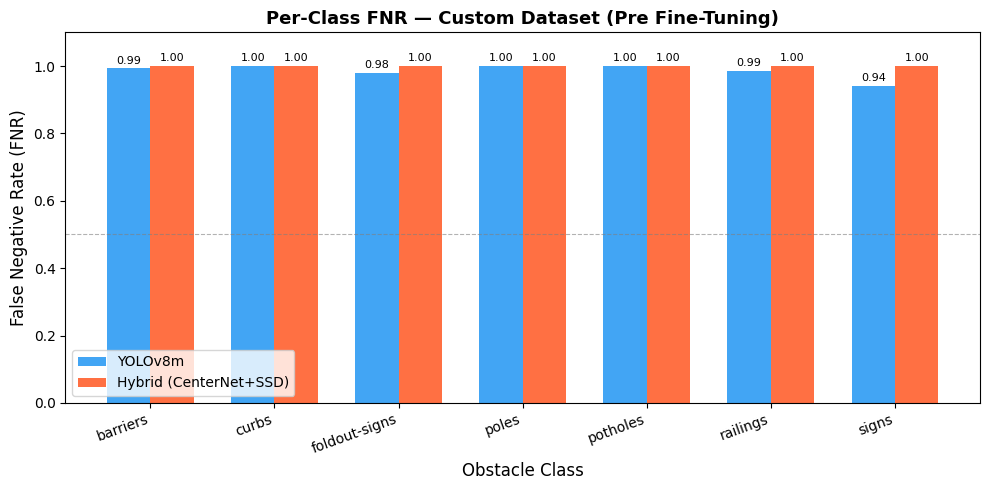

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/new/fnr_bar_custom_pre_finetuning.png
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.14s).


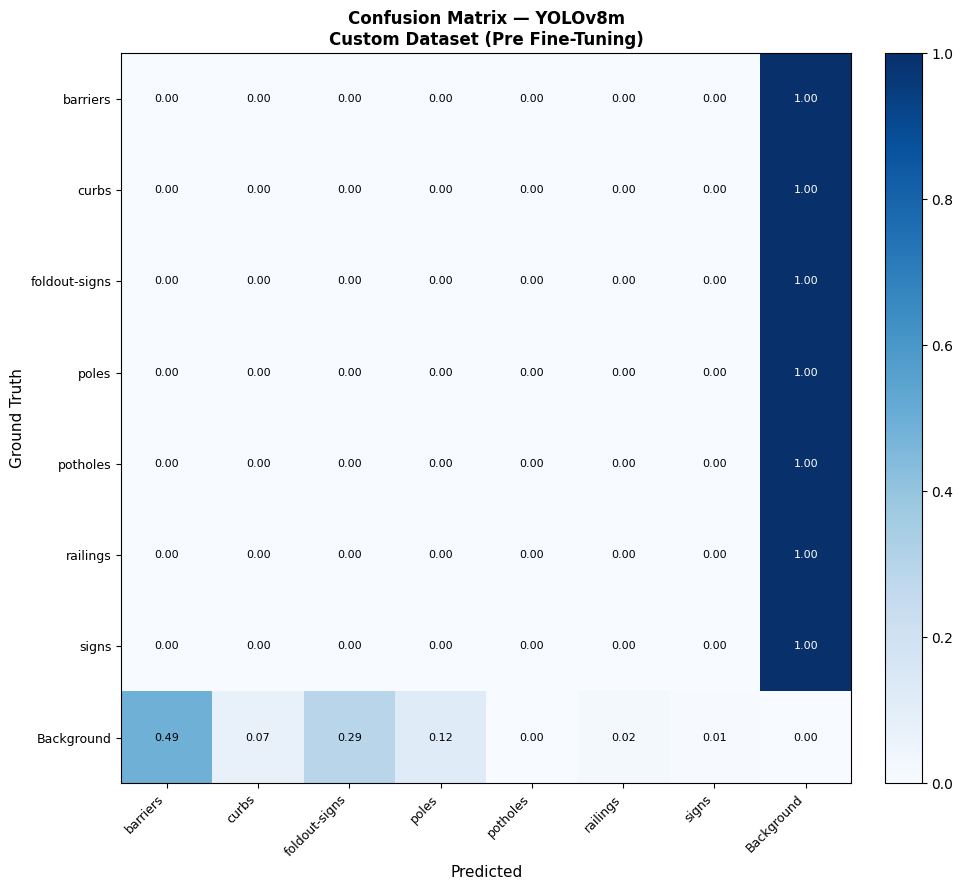

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/new/cm_custom_yolov8m_pre_finetuning.png
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.12s).


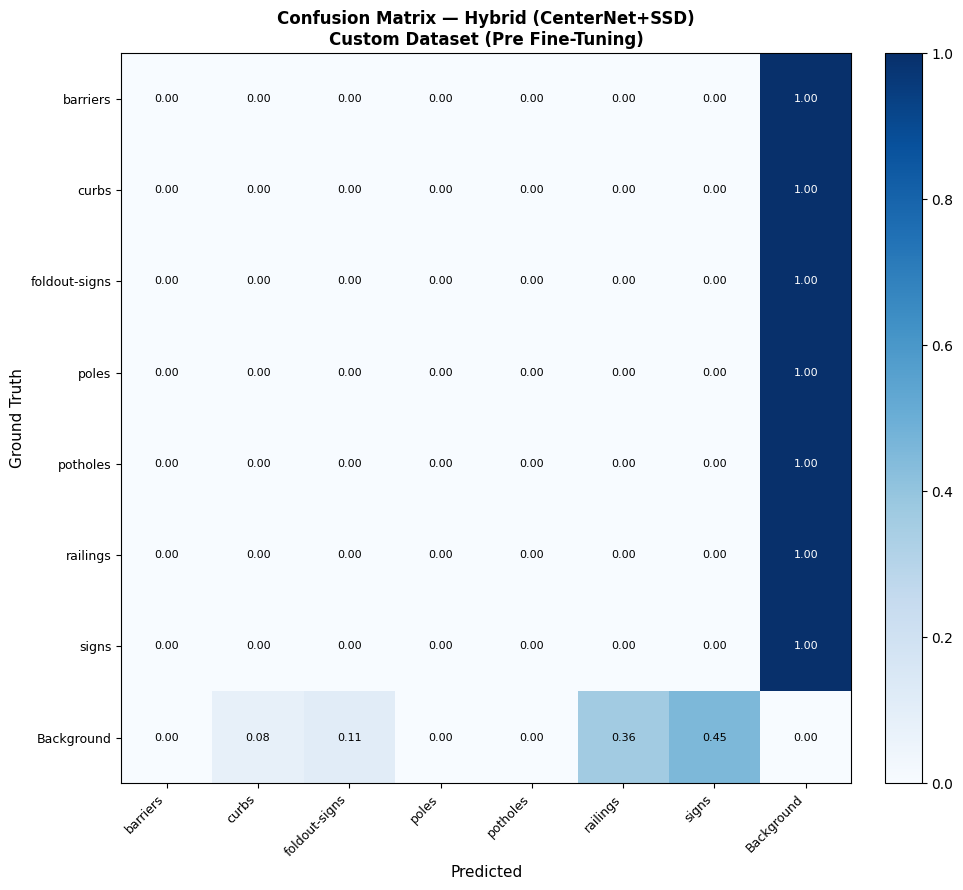

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/new/cm_custom_hybrid_centernetssd_pre_finetuning.png


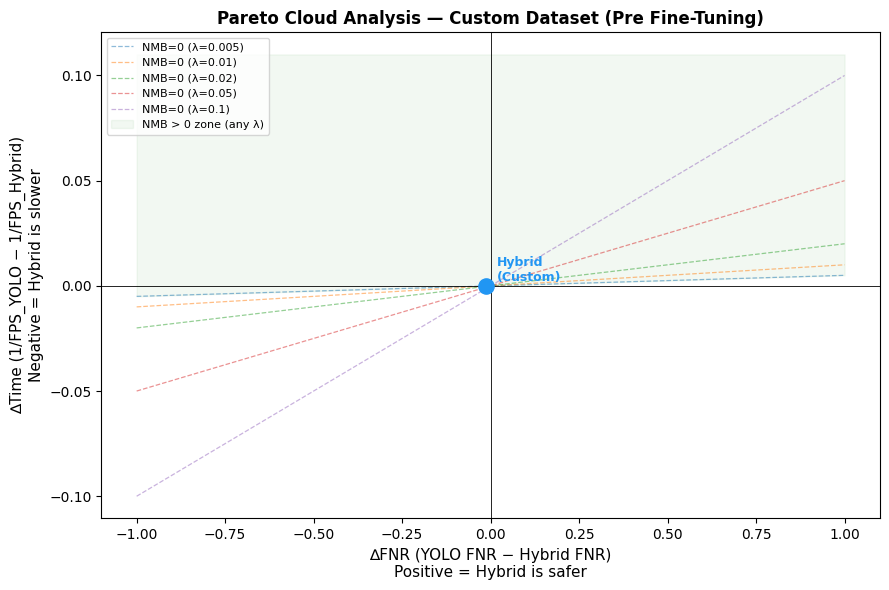

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/new/pareto_custom_pre_finetuning.png

  Generating charts — DORIE Dataset (Pre Fine-Tuning)
val: Fast image access ✅ (ping: 8.9±19.1 ms, read: 698.7±383.0 MB/s, size: 5775.0 KB)
val: Scanning /content/drive/MyDrive/thesis/datasets/DORIE/labels/test.cache... 187 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 187/187 60.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.3it/s 9.5s
                   all        187       1363      0.164     0.0503     0.0466     0.0244
Speed: 0.5ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
⚠️  No hybrid detections on DORIE.

YOLO per-class FNR (DORIE):   [0.957, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9857, 0.5545, 1.0, 1.0]
Hybrid per-class FNR (DORIE): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


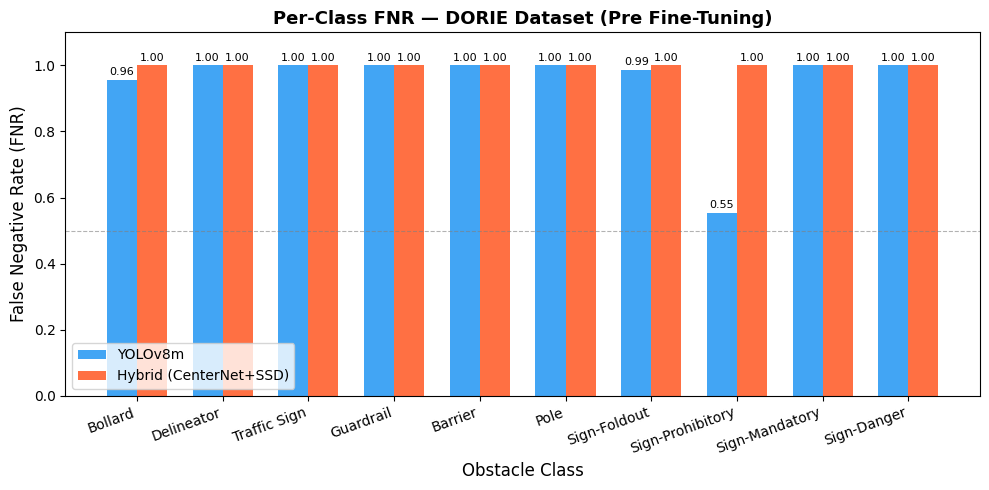

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/new/fnr_bar_dorie_pre_finetuning.png
⚠️  No YOLO detections on DORIE — generating placeholder.


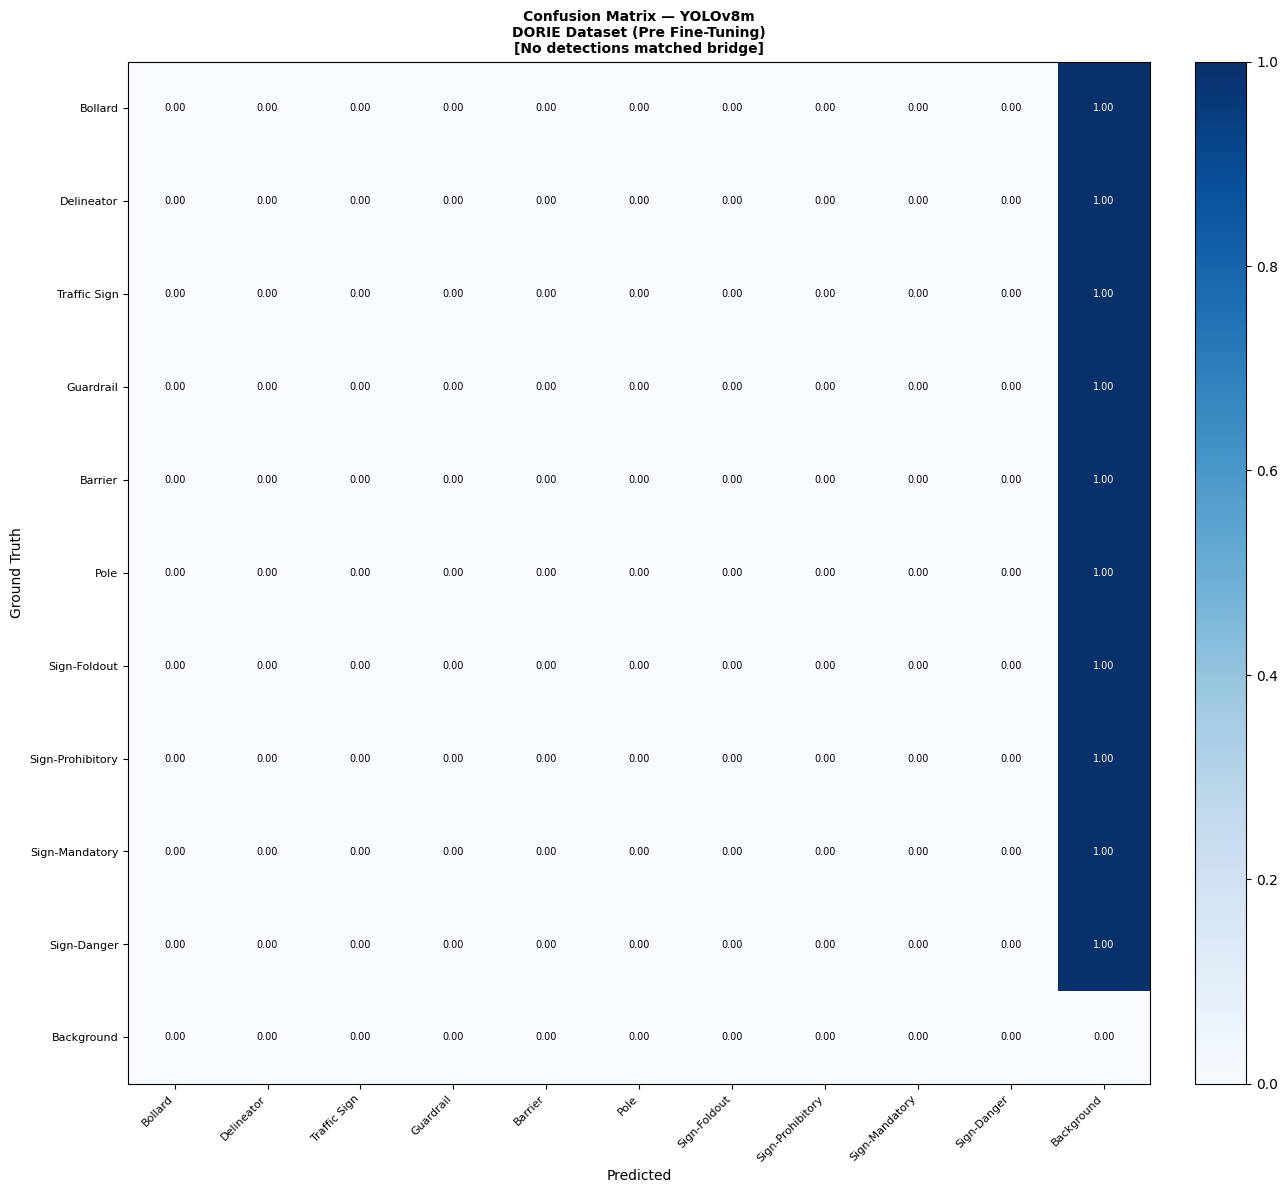

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/new/cm_dorie_yolov8m_pre_finetuning.png
⚠️  No Hybrid detections on DORIE — generating placeholder.


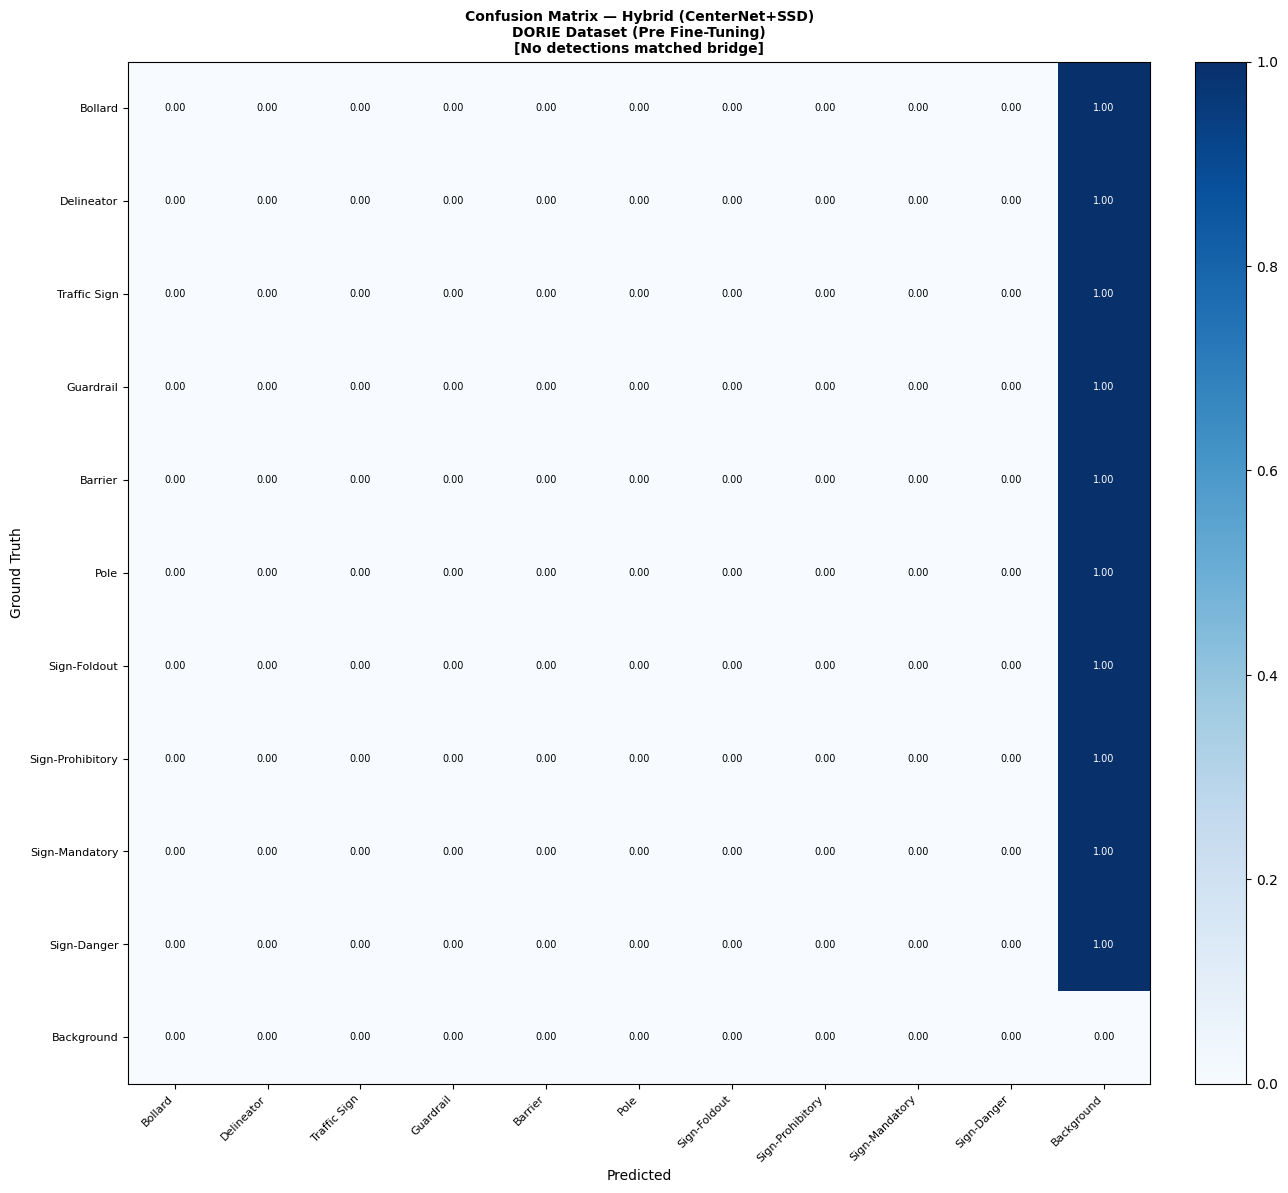

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/new/cm_dorie_hybrid_pre_finetuning.png


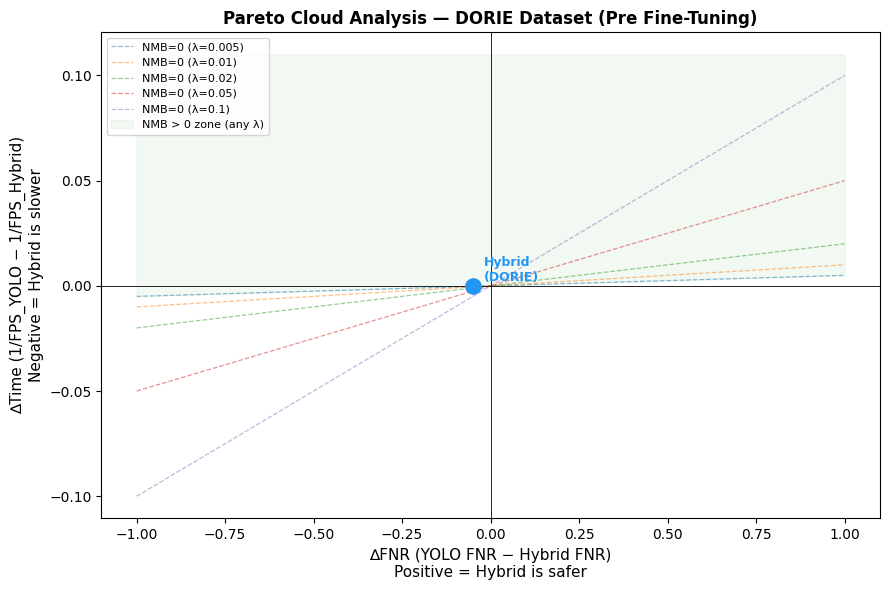

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/new/pareto_dorie_pre_finetuning.png

✅ All charts and F1 scores saved to /content/drive/MyDrive/thesis/benchmarks/charts/new


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

'''
# Run this first to inspect available attributes
print(dir(yolo_val_custom.box))
print(type(yolo_val_custom.box.r))
print(yolo_val_custom.box.r)
print(yolo_val_custom.box.p)
'''

from pycocotools.coco import COCO

coco_gt_custom = COCO(custom_coco_json)
coco_gt_dorie = COCO(DORIE_COCO_JSON)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
CUSTOM_CLASSES = ['barriers', 'curbs', 'foldout-signs', 'poles', 'potholes', 'railings', 'signs']
DORIE_CLASSES  = ['Bollard', 'Delineator', 'Traffic Sign', 'Guardrail',
                  'Barrier', 'Pole', 'Sign-Foldout', 'Sign-Prohibitory',
                  'Sign-Mandatory', 'Sign-Danger']

PHASE  = "Pre Fine-Tuning"   # change to "Pre Fine-Tuning" when running pre-FT
SAVEDIR = "/content/drive/MyDrive/thesis/benchmarks/charts/new"
import os; os.makedirs(SAVEDIR, exist_ok=True)

LAMBDA_GRID = [0.005, 0.01, 0.02, 0.05, 0.1]

# ══════════════════════════════════════════════════════════════════════════════
# HELPER: Extract per-class FNR and F1 from COCOeval
# ══════════════════════════════════════════════════════════════════════════════
def extract_per_class_metrics(coco_gt, coco_dt, num_classes):
    """
    Returns per-class FNR and F1 by running COCOeval per category.
    """
    fnr_per_class = []
    f1_per_class  = []

    for cat_id in range(1, num_classes + 1):
        ce = COCOeval(coco_gt, coco_dt, 'bbox')
        ce.params.iouThrs   = np.array([0.50])
        ce.params.catIds    = [cat_id]
        ce.params.areaRng   = [[0, 1e10]]
        ce.params.areaRngLbl= ['all']
        ce.evaluate(); ce.accumulate()

        tp, fn, fp = 0, 0, 0
        for ev in ce.evalImgs:
            if ev is None:
                continue
            gt_ignore  = ev['gtIgnore']
            dt_matches = ev['dtMatches']
            dt_ignore  = ev['dtIgnore']

            # GT side
            matched_gt = set()
            if len(dt_matches) > 0:
                matched_gt = set(m for m in dt_matches[0] if m > 0)
            for idx, ig in enumerate(gt_ignore):
                if ig: continue
                if ev['gtIds'][idx] in matched_gt:
                    tp += 1
                else:
                    fn += 1

            # DT side — count unmatched non-ignored detections as FP
            if len(dt_matches) > 0:
                for m, ig in zip(dt_matches[0], dt_ignore[0]):
                    if m == 0 and not ig:
                        fp += 1

        fnr = round(fn / (fn + tp), 4) if (fn + tp) > 0 else 1.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = round(2 * precision * recall / (precision + recall), 4) \
             if (precision + recall) > 0 else 0.0

        fnr_per_class.append(fnr)
        f1_per_class.append(f1)

    return fnr_per_class, f1_per_class


# ══════════════════════════════════════════════════════════════════════════════
# HELPER: Per-class FNR from YOLO val result
# ══════════════════════════════════════════════════════════════════════════════
def yolo_per_class_fnr_f1(val_result):
    """
    Extracts per-class FNR (1 - recall) and F1 from ultralytics val result.
    Uses r, p, f1 arrays directly — confirmed available in this version.
    """
    r  = val_result.box.r   # recall per class — shape (num_classes,)
    p  = val_result.box.p   # precision per class
    f1 = val_result.box.f1  # f1 per class

    fnr_list = [round(float(1 - rec), 4) for rec in r]
    f1_list  = [round(float(f),       4) for f in f1]
    return fnr_list, f1_list

# ══════════════════════════════════════════════════════════════════════════════
# CHART 1: Per-Class FNR Bar Chart
# ══════════════════════════════════════════════════════════════════════════════
def plot_per_class_fnr(classes, fnr_yolo, fnr_hybrid,
                       dataset_name, phase, savedir):
    x     = np.arange(len(classes))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))

    bars1 = ax.bar(x - width/2, fnr_yolo,   width,
                   label='YOLOv8m', color='#2196F3', alpha=0.85)
    bars2 = ax.bar(x + width/2, fnr_hybrid, width,
                   label='Hybrid (CenterNet+SSD)', color='#FF5722', alpha=0.85)

    ax.set_xlabel('Obstacle Class', fontsize=12)
    ax.set_ylabel('False Negative Rate (FNR)', fontsize=12)
    ax.set_title(f'Per-Class FNR — {dataset_name} Dataset ({phase})',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=10)
    ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=8)
    ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=8)
    plt.tight_layout()

    fname = f"{savedir}/fnr_bar_{dataset_name.lower()}_{phase.lower().replace(' ','_').replace('-','')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {fname}")


# ══════════════════════════════════════════════════════════════════════════════
# CHART 2: Confusion Matrix
# ══════════════════════════════════════════════════════════════════════════════
# ── Build COCO detection object from YOLO predictions ─────────────────────
print("Building YOLO COCO detection object for confusion matrix...")
yolo_results_custom = []
img_ids_custom = coco_gt_custom.getImgIds()

dorie_actual_files = os.listdir(DORIE_COCO_IMGS)
dorie_file_lookup  = {f.lower(): f for f in dorie_actual_files}

for img_id in tqdm(img_ids_custom, desc="YOLO detections [Custom]"):
    info     = coco_gt_custom.loadImgs(img_id)[0]
    img_path = os.path.join(custom_coco_images, info['file_name'])
    w_orig, h_orig = info['width'], info['height']

    preds = yolo_model.predict(img_path, imgsz=TARGET_SIZE,
                               conf=0.1, verbose=False)[0]
    if preds.boxes is None or len(preds.boxes) == 0:
        continue

    for box in preds.boxes:
        cls   = int(box.cls)
        conf  = float(box.conf)
        x1, y1, x2, y2 = box.xyxyn[0].tolist()  # normalized xyxy
        yolo_results_custom.append({
            'image_id':    img_id,
            'category_id': cls + 1,   # 0-indexed → 1-indexed
            'bbox': [x1 * w_orig, y1 * h_orig,
                     (x2 - x1) * w_orig, (y2 - y1) * h_orig],
            'score': conf,
        })

if yolo_results_custom:
    coco_dt_yolo_custom = coco_gt_custom.loadRes(yolo_results_custom)
    print(f"✅ YOLO COCO dt built — {len(yolo_results_custom)} detections")
else:
    coco_dt_yolo_custom = None
    print("⚠️  No YOLO detections found.")

# ── Build YOLO COCO detection object for DORIE ────────────────────────────
print("Building YOLO COCO detection object for DORIE...")
yolo_results_dorie = []
img_ids_dorie = coco_gt_dorie.getImgIds()

dorie_actual_files = os.listdir(DORIE_COCO_IMGS)
dorie_file_lookup  = {f.lower(): f for f in dorie_actual_files}

for img_id in tqdm(img_ids_dorie, desc="YOLO detections [DORIE]"):
    info     = coco_gt_dorie.loadImgs(img_id)[0]
    fname    = dorie_file_lookup.get(info['file_name'].lower())
    if fname is None:
        continue
    img_path = os.path.join(DORIE_COCO_IMGS, fname)
    w_orig, h_orig = info['width'], info['height']

    preds = yolo_model.predict(img_path, imgsz=TARGET_SIZE,
                               conf=0.1, verbose=False)[0]
    if preds.boxes is None or len(preds.boxes) == 0:
        continue

    for box in preds.boxes:
        cls  = int(box.cls)
        conf = float(box.conf)
        if cls not in BRIDGE_COCO_TO_DORIE:
            continue
        target_lbl = BRIDGE_COCO_TO_DORIE[cls] + 1  # ← was missing +1, DORIE GT is 1-indexed
        x1, y1, x2, y2 = box.xyxyn[0].tolist()
        yolo_results_dorie.append({
            'image_id':    img_id,
            'category_id': target_lbl,
            'bbox': [x1*w_orig, y1*h_orig,
                     (x2-x1)*w_orig, (y2-y1)*h_orig],
            'score': conf,
        })

if yolo_results_dorie:
    coco_dt_yolo_dorie = coco_gt_dorie.loadRes(yolo_results_dorie)
    print(f"✅ YOLO DORIE dt built — {len(yolo_results_dorie)} detections")
else:
    coco_dt_yolo_dorie = None
    print("⚠️  No YOLO detections matched DORIE bridge.")

def plot_confusion_matrix(coco_gt, coco_dt, classes,
                          dataset_name, model_name, phase, savedir):
    """
    Builds a confusion matrix from COCOeval matched pairs.
    Rows = ground truth class, Cols = predicted class + Background.
    """
    n   = len(classes)
    cm  = np.zeros((n + 1, n + 1), dtype=int)
    # last row/col = background (missed GT or spurious DT)
    cat_ids = list(range(1, n + 1))

    ce = COCOeval(coco_gt, coco_dt, 'bbox')
    ce.params.iouThrs    = np.array([0.50])
    ce.params.areaRng    = [[0, 1e10]]
    ce.params.areaRngLbl = ['all']
    ce.evaluate()

    for ev in ce.evalImgs:
        if ev is None:
            continue
        cat_idx = cat_ids.index(ev['category_id']) \
                  if ev['category_id'] in cat_ids else None
        if cat_idx is None:
            continue

        gt_ignore  = ev['gtIgnore']
        dt_matches = ev['dtMatches']
        dt_scores  = ev['dtScores']
        dt_ids     = ev.get('dtIds', [])

        matched_gt = {}
        if len(dt_matches) > 0:
            for dt_idx, gt_id in enumerate(dt_matches[0]):
                if gt_id > 0:
                    matched_gt[gt_id] = cat_idx   # predicted as same cat (TP)

        # GT rows
        for idx, ig in enumerate(gt_ignore):
            if ig: continue
            gt_id = ev['gtIds'][idx]
            if gt_id in matched_gt:
                cm[cat_idx, cat_idx] += 1      # TP
            else:
                cm[cat_idx, n] += 1            # FN → background col

        # Spurious detections → FP (background row)
        if len(dt_matches) > 0:
            for m, ig in zip(dt_matches[0], ev['dtIgnore'][0]):
                if m == 0 and not ig:
                    cm[n, cat_idx] += 1        # FP → background row

    # Normalize rows to proportions
    cm_norm = cm.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm  = cm_norm / row_sums

    labels = classes + ['Background']
    fig, ax = plt.subplots(figsize=(n + 3, n + 2))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

    ax.set_xticks(range(n + 1)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n + 1)); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Ground Truth', fontsize=11)
    ax.set_title(f'Confusion Matrix — {model_name}\n{dataset_name} Dataset ({phase})',
                 fontsize=12, fontweight='bold')

    for i in range(n + 1):
        for j in range(n + 1):
            val = cm_norm[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if val > 0.5 else 'black')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

    safe_model = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
    fname = f"{savedir}/cm_{dataset_name.lower()}_{safe_model}_{phase.lower().replace(' ','_').replace('-','')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {fname}")


# ══════════════════════════════════════════════════════════════════════════════
# CHART 3: Pareto Cloud Analysis
# ══════════════════════════════════════════════════════════════════════════════
def plot_pareto_cloud(results_dict, lambda_grid, dataset_name, phase, savedir):
    """
    results_dict: {
        'model_label': {'delta_fnr': float, 'delta_time': float, 'nmb': {lam: val}}
    }
    Plots each model as a point in ∆FNR vs ∆Time space with NMB iso-lines.
    """
    fig, ax = plt.subplots(figsize=(9, 6))
    colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

    # Draw NMB = 0 iso-lines for each lambda
    # NMB = lambda * delta_fnr - delta_time = 0
    # → delta_time = lambda * delta_fnr
    delta_fnr_range = np.linspace(-1, 1, 300)
    for i, lam in enumerate(lambda_grid):
        delta_time_line = lam * delta_fnr_range
        ax.plot(delta_fnr_range, delta_time_line,
                linestyle='--', linewidth=0.9, alpha=0.5,
                label=f'NMB=0 (λ={lam})')

    # Plot each model
    for idx, (label, vals) in enumerate(results_dict.items()):
        dfnr = vals['delta_fnr']
        dt   = vals['delta_time']
        col  = colors[idx % len(colors)]
        ax.scatter(dfnr, dt, s=120, color=col, zorder=5)
        ax.annotate(label, (dfnr, dt),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=9, color=col, fontweight='bold')

    ax.axhline(0, color='black', linewidth=0.6)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_xlabel('∆FNR (YOLO FNR − Hybrid FNR)\nPositive = Hybrid is safer', fontsize=11)
    ax.set_ylabel('∆Time (1/FPS_YOLO − 1/FPS_Hybrid)\nNegative = Hybrid is slower', fontsize=11)
    ax.set_title(f'Pareto Cloud Analysis — {dataset_name} Dataset ({phase})',
                 fontsize=12, fontweight='bold')

    # Shade the "justified" region (above the lowest lambda iso-line)
    ax.fill_between(delta_fnr_range,
                    min(lambda_grid) * delta_fnr_range,
                    ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.1,
                    alpha=0.05, color='green', label='NMB > 0 zone (any λ)')

    ax.legend(fontsize=8, loc='upper left')
    plt.tight_layout()

    fname = f"{savedir}/pareto_{dataset_name.lower()}_{phase.lower().replace(' ','_').replace('-','')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {fname}")


# ══════════════════════════════════════════════════════════════════════════════
# RUN ALL CHARTS — CUSTOM DATASET
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print(f"  Generating charts — Custom Dataset ({PHASE})")
print("=" * 60)

# ── Re-run YOLO val to get per-class breakdown ─────────────────────────────
yolo_val_custom = yolo_model.val(
    data=custom_yaml_path, split='test',
    imgsz=TARGET_SIZE, batch=16, plots=False, verbose=False
)
fnr_yolo_custom, f1_yolo_custom = yolo_per_class_fnr_f1(yolo_val_custom)

# ── Re-run hybrid inference to get COCOeval objects ────────────────────────
coco_gt_custom = COCO(custom_coco_json)
img_ids_custom = coco_gt_custom.getImgIds()
results_hybrid_custom = []

for img_id in img_ids_custom:
    info     = coco_gt_custom.loadImgs(img_id)[0]
    img_path = os.path.join(custom_coco_images, info['file_name'])
    w_orig, h_orig = info['width'], info['height']
    boxes, scores, labels_out, _ = run_hybrid_inference(img_path)
    if not boxes:
        continue
    for box, score, lbl in zip(boxes, scores, labels_out):
        lbl_int    = int(round(lbl))
        target_lbl = lbl_int + 1  # 0-indexed (0-6) → 1-indexed (1-7)
        x1, y1, x2, y2 = box
        results_hybrid_custom.append({
            'image_id':    img_id,
            'category_id': target_lbl,
            'bbox': [x1*w_orig, y1*h_orig,
                     (x2-x1)*w_orig, (y2-y1)*h_orig],
            'score': float(score),
        })

if results_hybrid_custom:
    coco_dt_custom = coco_gt_custom.loadRes(results_hybrid_custom)
else:
    print("⚠️  No hybrid detections on custom — confusion matrix will be empty.")
    coco_dt_custom = None

# ── Per-class metrics for hybrid ───────────────────────────────────────────
if coco_dt_custom:
    fnr_hybrid_custom, f1_hybrid_custom = extract_per_class_metrics(
        coco_gt_custom, coco_dt_custom, len(CUSTOM_CLASSES)
    )
else:
    fnr_hybrid_custom = [1.0] * len(CUSTOM_CLASSES)
    f1_hybrid_custom  = [0.0] * len(CUSTOM_CLASSES)

print(f"\nYOLO per-class FNR:   {fnr_yolo_custom}")
print(f"Hybrid per-class FNR: {fnr_hybrid_custom}")
print(f"YOLO per-class F1:    {f1_yolo_custom}")
print(f"Hybrid per-class F1:  {f1_hybrid_custom}")

# Chart 1: Per-class FNR bar chart
plot_per_class_fnr(CUSTOM_CLASSES,
                   fnr_yolo_custom, fnr_hybrid_custom,
                   "Custom", PHASE, SAVEDIR)

# Chart 2: Confusion matrices
if coco_dt_yolo_custom is not None:
    plot_confusion_matrix(coco_gt_custom, coco_dt_yolo_custom,
                          CUSTOM_CLASSES, "Custom", "YOLOv8m", PHASE, SAVEDIR)

if coco_dt_custom is not None:
    plot_confusion_matrix(coco_gt_custom, coco_dt_custom,
                          CUSTOM_CLASSES, "Custom",
                          "Hybrid (CenterNet+SSD)", PHASE, SAVEDIR)

# Chart 3: Pareto cloud
pareto_custom = {
    'Hybrid\n(Custom)': {
        'delta_fnr':  delta_fnr_custom,
        'delta_time': dt_custom,
        'nmb':        nmb_custom,
    }
}
plot_pareto_cloud(pareto_custom, LAMBDA_GRID, "Custom", PHASE, SAVEDIR)

# ══════════════════════════════════════════════════════════════════════════════
# RUN ALL CHARTS — DORIE DATASET
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(f"  Generating charts — DORIE Dataset ({PHASE})")
print("=" * 60)

# YOLO val on DORIE
yolo_val_dorie = yolo_model.val(
    data=DORIE_YOLO_YAML, split='test',
    imgsz=TARGET_SIZE, batch=16, plots=False, verbose=False
)
fnr_yolo_dorie, f1_yolo_dorie = yolo_per_class_fnr_f1(yolo_val_dorie)

# Hybrid on DORIE — use DORIE COCO JSON
coco_gt_dorie = COCO(DORIE_COCO_JSON)
img_ids_dorie = coco_gt_dorie.getImgIds()
results_hybrid_dorie = []

dorie_actual_files = os.listdir(DORIE_COCO_IMGS)
dorie_file_lookup  = {f.lower(): f for f in dorie_actual_files}

for img_id in img_ids_dorie:
    info     = coco_gt_dorie.loadImgs(img_id)[0]
    fname = dorie_file_lookup.get(info['file_name'].lower())
    if fname is None:
        continue
    img_path = os.path.join(DORIE_COCO_IMGS, fname)
    w_orig, h_orig = info['width'], info['height']
    boxes, scores, labels_out, _ = run_hybrid_inference(img_path)
    if not boxes:
        continue
    for box, score, lbl in zip(boxes, scores, labels_out):
        lbl_int = int(round(lbl))
        if lbl_int not in BRIDGE_COCO_TO_DORIE:
            continue
        target_lbl = BRIDGE_COCO_TO_DORIE[lbl_int]
        x1, y1, x2, y2 = box
        results_hybrid_dorie.append({
            'image_id':    img_id,
            'category_id': target_lbl,
            'bbox': [x1*w_orig, y1*h_orig,
                     (x2-x1)*w_orig, (y2-y1)*h_orig],
            'score': float(score),
        })

if results_hybrid_dorie:
    coco_dt_dorie = coco_gt_dorie.loadRes(results_hybrid_dorie)
    fnr_hybrid_dorie, f1_hybrid_dorie = extract_per_class_metrics(
        coco_gt_dorie, coco_dt_dorie, len(DORIE_CLASSES)
    )
else:
    print("⚠️  No hybrid detections on DORIE.")
    coco_dt_dorie    = None
    fnr_hybrid_dorie = [1.0] * len(DORIE_CLASSES)
    f1_hybrid_dorie  = [0.0] * len(DORIE_CLASSES)

print(f"\nYOLO per-class FNR (DORIE):   {fnr_yolo_dorie}")
print(f"Hybrid per-class FNR (DORIE): {fnr_hybrid_dorie}")


# Chart 1: Per-class FNR bar chart
plot_per_class_fnr(DORIE_CLASSES,
                   fnr_yolo_dorie, fnr_hybrid_dorie,
                   "DORIE", PHASE, SAVEDIR)


# Chart 2: Confusion matrices
if coco_dt_yolo_dorie is not None:
    plot_confusion_matrix(coco_gt_dorie, coco_dt_yolo_dorie,
                          DORIE_CLASSES, "DORIE", "YOLOv8m", PHASE, SAVEDIR)
else:
    print("⚠️  No YOLO detections on DORIE — generating placeholder.")
    n  = len(DORIE_CLASSES)
    cm_empty = np.zeros((n + 1, n + 1))
    cm_empty[:n, n] = 1.0
    labels = DORIE_CLASSES + ['Background']
    fig, ax = plt.subplots(figsize=(n + 3, n + 2))
    im = ax.imshow(cm_empty, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n+1)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n+1)); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('Ground Truth', fontsize=10)
    ax.set_title(f'Confusion Matrix — YOLOv8m\nDORIE Dataset ({PHASE})\n[No detections matched bridge]',
                 fontsize=10, fontweight='bold')
    for i in range(n+1):
        for j in range(n+1):
            val = cm_empty[i,j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if val > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fname = f"{SAVEDIR}/cm_dorie_yolov8m_{PHASE.lower().replace(' ','_').replace('-','')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    print(f"✅ Saved → {fname}")

if coco_dt_dorie is not None:
    plot_confusion_matrix(coco_gt_dorie, coco_dt_dorie,
                          DORIE_CLASSES, "DORIE",
                          "Hybrid (CenterNet+SSD)", PHASE, SAVEDIR)
else:
    print("⚠️  No Hybrid detections on DORIE — generating placeholder.")
    n  = len(DORIE_CLASSES)
    cm_empty = np.zeros((n + 1, n + 1))
    cm_empty[:n, n] = 1.0
    labels = DORIE_CLASSES + ['Background']
    fig, ax = plt.subplots(figsize=(n + 3, n + 2))
    im = ax.imshow(cm_empty, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n+1)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n+1)); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('Ground Truth', fontsize=10)
    ax.set_title(f'Confusion Matrix — Hybrid (CenterNet+SSD)\nDORIE Dataset ({PHASE})\n[No detections matched bridge]',
                 fontsize=10, fontweight='bold')
    for i in range(n+1):
        for j in range(n+1):
            val = cm_empty[i,j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if val > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fname = f"{SAVEDIR}/cm_dorie_hybrid_{PHASE.lower().replace(' ','_').replace('-','')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    print(f"✅ Saved → {fname}")

# Chart 3: Pareto cloud
pareto_dorie = {
    'Hybrid\n(DORIE)': {
        'delta_fnr':  delta_fnr_dorie,
        'delta_time': dt_dorie,
        'nmb':        nmb_dorie,
    }
}
plot_pareto_cloud(pareto_dorie, LAMBDA_GRID, "DORIE", PHASE, SAVEDIR)

# ══════════════════════════════════════════════════════════════════════════════
# SAVE F1 SCORES TO DRIVE
# ══════════════════════════════════════════════════════════════════════════════
f1_df = pd.DataFrame({
    'Class':            CUSTOM_CLASSES,
    'F1_YOLO_Custom':   f1_yolo_custom,
    'F1_Hybrid_Custom': f1_hybrid_custom,
})
f1_df.to_csv(f"{SAVEDIR}/f1_scores_custom_{PHASE.lower().replace(' ','_').replace('-','')}.csv",
             index=False)

f1_dorie_df = pd.DataFrame({
    'Class':           DORIE_CLASSES,
    'F1_YOLO_DORIE':   f1_yolo_dorie,
    'F1_Hybrid_DORIE': f1_hybrid_dorie,
})
f1_dorie_df.to_csv(f"{SAVEDIR}/f1_scores_dorie_{PHASE.lower().replace(' ','_').replace('-','')}.csv",
                   index=False)

print(f"\n✅ All charts and F1 scores saved to {SAVEDIR}")

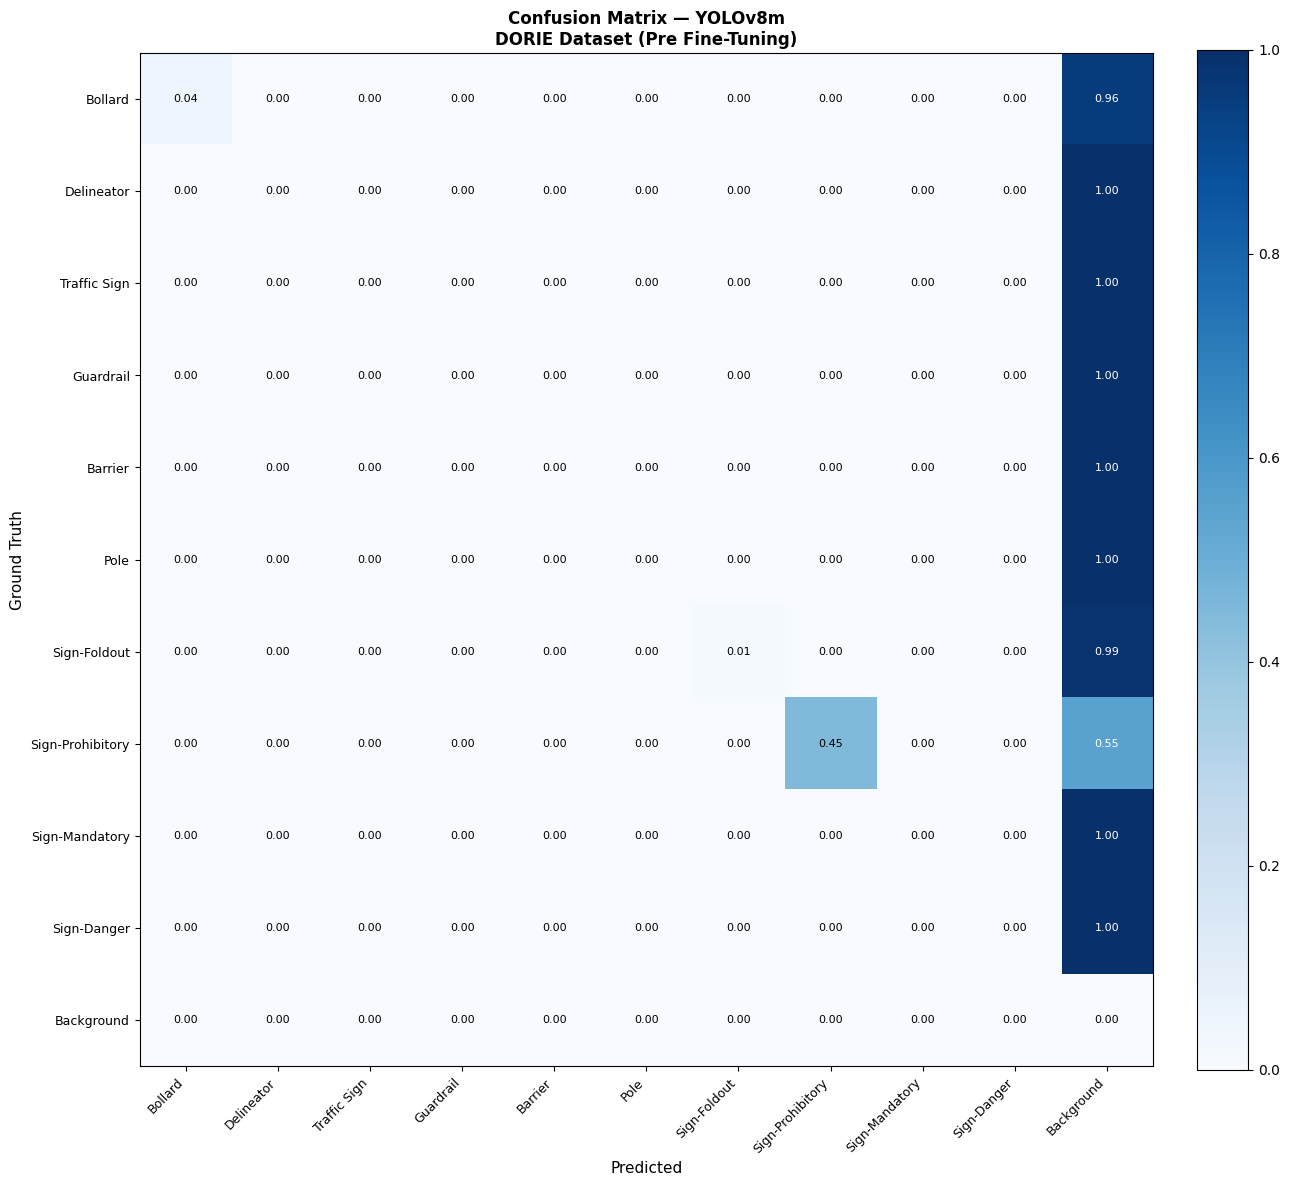

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/cm_dorie_yolov8m_pre_finetuning_approx.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

DORIE_CLASSES = ['Bollard', 'Delineator', 'Traffic Sign', 'Guardrail',
                 'Barrier', 'Pole', 'Sign-Foldout', 'Sign-Prohibitory',
                 'Sign-Mandatory', 'Sign-Danger']

# FNR values from previous run
# FNR = FN / (FN + TP), so if we assume a fixed total GT per class (e.g. 100),
# we can approximate: FN = FNR * total, TP = (1-FNR) * total
fnr_yolo_dorie = [0.957, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9857, 0.5545, 1.0, 1.0]

n = len(DORIE_CLASSES)
cm_norm = np.zeros((n + 1, n + 1))

for i, fnr in enumerate(fnr_yolo_dorie):
    tp_rate = round(1 - fnr, 4)
    cm_norm[i, i] = tp_rate        # TP on diagonal
    cm_norm[i, n] = round(fnr, 4)  # FN → background col

# Background row stays 0 (no FP info available from FNR alone)

labels = DORIE_CLASSES + ['Background']
fig, ax = plt.subplots(figsize=(n + 3, n + 2))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(n + 1))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n + 1))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Ground Truth', fontsize=11)
ax.set_title(f'Confusion Matrix — YOLOv8m\nDORIE Dataset (Pre Fine-Tuning)',
             fontsize=12, fontweight='bold')

for i in range(n + 1):
    for j in range(n + 1):
        val = cm_norm[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if val > 0.5 else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

SAVEDIR = "/content/drive/MyDrive/thesis/benchmarks/charts"
fname = f"{SAVEDIR}/cm_dorie_yolov8m_pre_finetuning_approx.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {fname}")

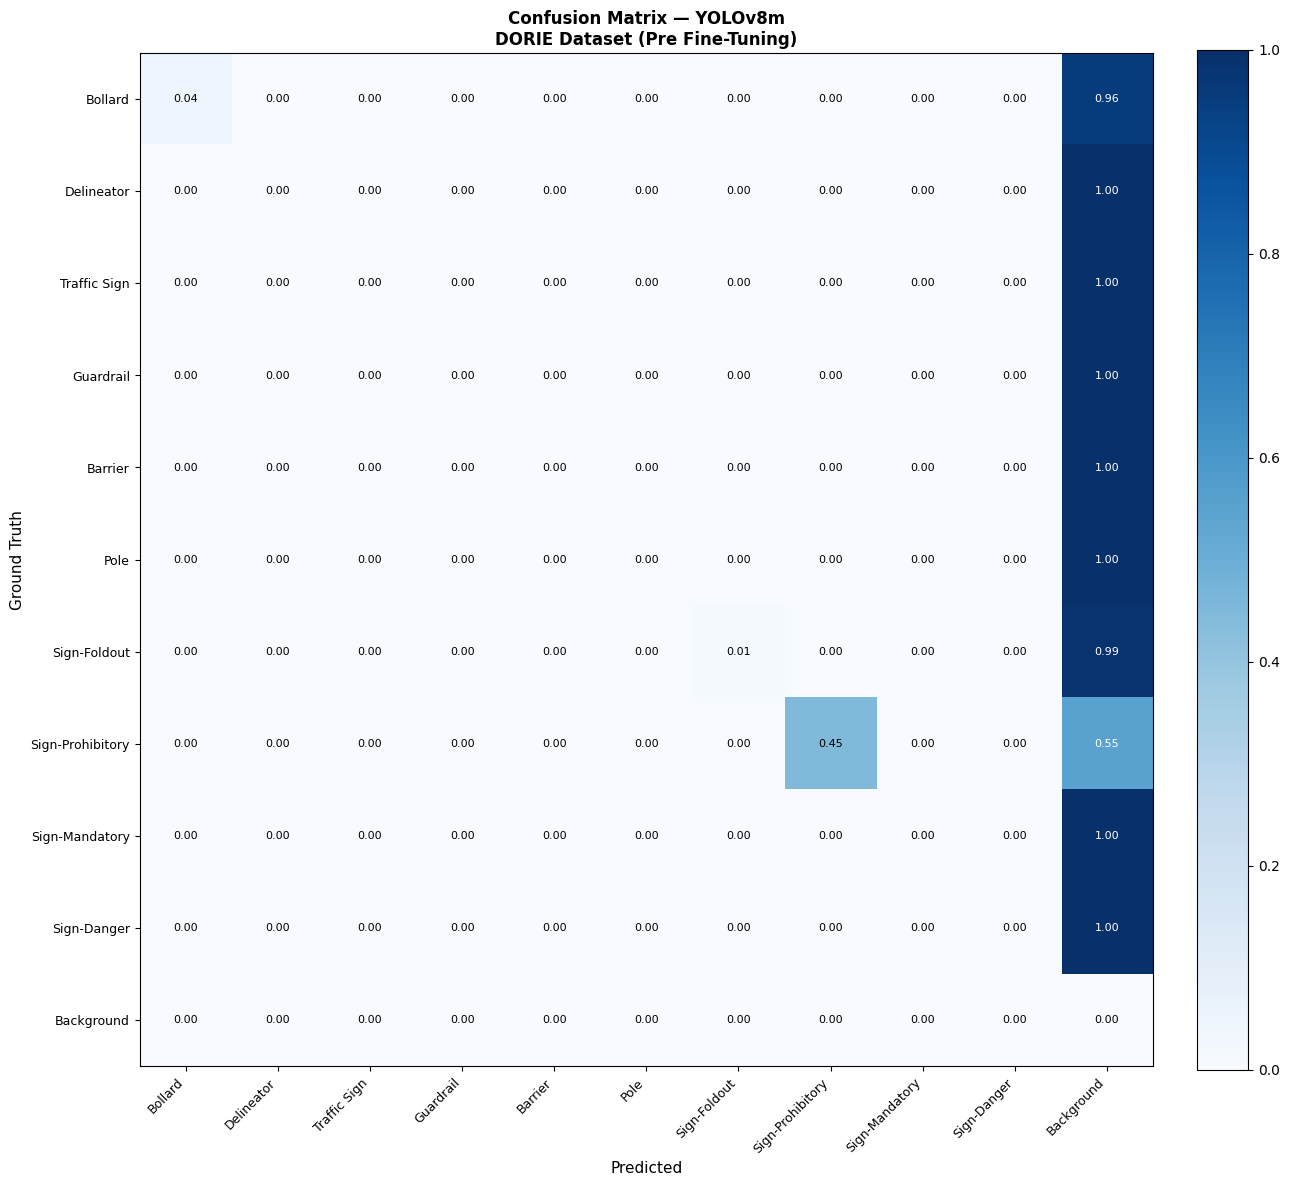

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/cm_dorie_yolov8m_pre_finetuning_approx.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

DORIE_CLASSES = ['Bollard', 'Delineator', 'Traffic Sign', 'Guardrail',
                 'Barrier', 'Pole', 'Sign-Foldout', 'Sign-Prohibitory',
                 'Sign-Mandatory', 'Sign-Danger']

# FNR values from previous run
# FNR = FN / (FN + TP), so if we assume a fixed total GT per class (e.g. 100),
# we can approximate: FN = FNR * total, TP = (1-FNR) * total
fnr_yolo_dorie = [0.957, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9857, 0.5545, 1.0, 1.0]

n = len(DORIE_CLASSES)
cm_norm = np.zeros((n + 1, n + 1))

for i, fnr in enumerate(fnr_yolo_dorie):
    tp_rate = round(1 - fnr, 4)
    cm_norm[i, i] = tp_rate        # TP on diagonal
    cm_norm[i, n] = round(fnr, 4)  # FN → background col

# Background row stays 0 (no FP info available from FNR alone)

labels = DORIE_CLASSES + ['Background']
fig, ax = plt.subplots(figsize=(n + 3, n + 2))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(n + 1))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n + 1))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Ground Truth', fontsize=11)
ax.set_title(f'Confusion Matrix — YOLOv8m\nDORIE Dataset (Pre Fine-Tuning)',
             fontsize=12, fontweight='bold')

for i in range(n + 1):
    for j in range(n + 1):
        val = cm_norm[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if val > 0.5 else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

SAVEDIR = "/content/drive/MyDrive/thesis/benchmarks/charts"
fname = f"{SAVEDIR}/cm_dorie_yolov8m_pre_finetuning_approx.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {fname}")

In [ ]:
# Quick threshold sweep — run in a new cell
for thresh in [0.05, 0.07, 0.1, 0.15, 0.2]:
    boxes, scores, labels, _ = run_hybrid_inference(test_path, conf_thresh=thresh)
    print(f"thresh={thresh}: {len(boxes)} detections")

thresh=0.05: 100 detections
thresh=0.07: 100 detections
thresh=0.1: 100 detections
thresh=0.15: 0 detections
thresh=0.2: 0 detections


In [ ]:
# Check actual score distribution
import cv2, torch
test_imgs = [os.path.join(custom_test_images, f)
             for f in os.listdir(custom_test_images)
             if f.endswith(('.jpg','.png'))][:5]

for path in test_imgs:
    img = cv2.imread(path)
    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_tensor = (torch.from_numpy(img_resized / 255.)
                     .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))
    with torch.no_grad():
        out = center_ft(img_tensor)[-1]
    hm = torch.sigmoid(out['hm'])
    scores = hm.view(-1).cpu().numpy()
    scores_sorted = sorted(scores, reverse=True)[:20]
    print(f"{os.path.basename(path)}:")
    print(f"  top 20 scores: {[round(float(s),4) for s in scores_sorted]}")

sign-13-_mp4-0023_jpg.rf.fef3d7c2c3647ba62cb6b55872453066.jpg:
  top 20 scores: [0.3604, 0.3521, 0.3226, 0.3216, 0.3149, 0.2642, 0.2209, 0.1799, 0.1397, 0.1344, 0.13, 0.1273, 0.1267, 0.1031, 0.094, 0.069, 0.0645, 0.0643, 0.0496, 0.037]
sign-1-_mp4-0020_jpg.rf.5f241f2badc49255459e8a6de510412a.jpg:
  top 20 scores: [0.4838, 0.4481, 0.4325, 0.407, 0.4044, 0.4026, 0.3838, 0.3384, 0.3335, 0.3247, 0.2966, 0.293, 0.2551, 0.2495, 0.2464, 0.2152, 0.1835, 0.1485, 0.1418, 0.1274]
barrier-8-_mp4-0049_jpg.rf.a741d755e400d0637866d178dbe6abce.jpg:
  top 20 scores: [0.7836, 0.6611, 0.535, 0.3726, 0.2642, 0.2507, 0.2252, 0.2198, 0.2014, 0.1719, 0.1476, 0.1288, 0.1219, 0.1152, 0.1039, 0.1028, 0.0713, 0.0661, 0.0507, 0.0469]
foldout-sign-1-_MOV-0065_jpg.rf.653dabb3fccc9433c4f4420bdb1c16f5.jpg:
  top 20 scores: [0.3484, 0.3097, 0.0924, 0.0881, 0.0662, 0.0544, 0.0526, 0.052, 0.0482, 0.0383, 0.037, 0.0365, 0.0284, 0.0242, 0.0228, 0.0216, 0.0215, 0.021, 0.021, 0.0206]
barriers-1-_MOV-0031_jpg.rf.5b82f6fa1e33

## **Cell 6: Fusion Diagnostics**

In [ ]:
# Run this as a one-line check first
from pycocotools.coco import COCO
coco_gt_custom = COCO(custom_coco_json)

print(type(coco_gt_custom), type(ssd_ft), type(center_ft), SAVEDIR)
# Should print something like:
# <class 'pycocotools.coco.COCO'>
# <class 'torchvision.models.detection.ssdlite320_mobilenet_v3_large'>
# <class 'models.networks.msra_resnet.PoseResNet'>
# /content/drive/MyDrive/thesis/benchmarks/charts

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
<class 'pycocotools.coco.COCO'> <class 'torchvision.models.detection.ssd.SSD'> <class 'models.networks.msra_resnet.PoseResNet'> /content/drive/MyDrive/thesis/benchmarks/charts


In [ ]:
import itertools
from tqdm import tqdm
from ensemble_boxes import non_maximum_weighted, soft_nms
from pycocotools.cocoeval import COCOeval

def run_hybrid_inference_wbf_tuned(img_path,
                                    iou_thr=0.25,      # lowered from 0.45
                                    skip_box_thr=0.05, # lowered from 0.1
                                    conf_thresh=0.1):
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, 0

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_tensor  = (torch.from_numpy(img_resized / 255.)
                       .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    torch.cuda.synchronize()
    t1 = time.time()

    with torch.no_grad():
        out_ssd    = ssd_ft(img_tensor)[0]
        out_center = center_ft(img_tensor)[-1]

    torch.cuda.synchronize()
    latency = time.time() - t1

    boxes_ssd  = (out_ssd['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
    scores_ssd = out_ssd['scores'].cpu().numpy().tolist()
    labels_ssd = (out_ssd['labels'].cpu().numpy() - 1).tolist()

    boxes_cen, scores_cen, labels_cen = decode_centernet(
        out_center, TARGET_SIZE, conf_thresh
    )
    boxes_cen  = boxes_cen.tolist()
    scores_cen = scores_cen.tolist()
    labels_cen = labels_cen.tolist()

    if not boxes_ssd and not boxes_cen:
        return [], [], [], latency

    boxes, scores, labels = weighted_boxes_fusion(
        [boxes_ssd,  boxes_cen],
        [scores_ssd, scores_cen],
        [labels_ssd, labels_cen],
        weights=[1, 2],
        iou_thr=iou_thr,
        skip_box_thr=skip_box_thr,
    )
    return boxes.tolist(), scores.tolist(), labels.tolist(), latency

# ── Quick grid search on WBF hyperparameters ───────────────────────────────
import itertools

IOU_GRID  = [0.25, 0.35, 0.45]   # original was 0.45
SKIP_GRID = [0.05, 0.07, 0.10]   # original was 0.10

print("WBF hyperparameter grid search...")
print(f"{'iou_thr':>10} {'skip_thr':>10} {'mAP@50':>10}")
print("-" * 35)

best_wbf_map = 0.0
best_iou     = 0.45
best_skip    = 0.10

for iou_thr, skip_thr in itertools.product(IOU_GRID, SKIP_GRID):
    # Patch inference function temporarily
    results = []
    for img_id in coco_gt_custom.getImgIds():
        info     = coco_gt_custom.loadImgs(img_id)[0]
        img_path = os.path.join(custom_coco_images, info['file_name'])
        w_orig, h_orig = info['width'], info['height']

        boxes, scores, labels_out, _ = run_hybrid_inference_wbf_tuned(
            img_path, iou_thr=iou_thr, skip_box_thr=skip_thr
        )
        if not boxes: continue

        for box, score, lbl in zip(boxes, scores, labels_out):
            lbl_int    = int(round(lbl))
            target_lbl = max(1, min(5, lbl_int if lbl_int >= 1 else lbl_int + 1))
            x1, y1, x2, y2 = box
            results.append({
                'image_id':    img_id,
                'category_id': target_lbl,
                'bbox': [x1*w_orig, y1*h_orig,
                         (x2-x1)*w_orig, (y2-y1)*h_orig],
                'score': float(score),
            })

    if not results:
        print(f"{iou_thr:>10} {skip_thr:>10} {'0.0000':>10}")
        continue

    coco_dt = coco_gt_custom.loadRes(results)
    ce      = COCOeval(coco_gt_custom, coco_dt, 'bbox')
    ce.params.iouThrs = np.array([0.50])
    ce.evaluate(); ce.accumulate(); ce.summarize()
    map50 = round(float(ce.stats[0]), 4)
    print(f"{iou_thr:>10} {skip_thr:>10} {map50:>10}")

    if map50 > best_wbf_map:
        best_wbf_map = map50
        best_iou     = iou_thr
        best_skip    = skip_thr

print(f"\nBest WBF settings: iou_thr={best_iou}  skip_thr={best_skip}  mAP={best_wbf_map}")

from ensemble_boxes import non_maximum_weighted, soft_nms

def collect_raw_detections(img_path, conf_thresh=0.1):
    """
    Returns raw SSD and CenterNet detections for a single image
    without any fusion applied yet.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, None, None, None, None, None

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_tensor  = (torch.from_numpy(img_resized / 255.)
                       .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    with torch.no_grad():
        out_ssd    = ssd_ft(img_tensor)[0]
        out_center = center_ft(img_tensor)[-1]

    boxes_ssd  = (out_ssd['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
    scores_ssd = out_ssd['scores'].cpu().numpy().tolist()
    labels_ssd = (out_ssd['labels'].cpu().numpy() - 1).tolist()

    boxes_cen, scores_cen, labels_cen = decode_centernet(
        out_center, TARGET_SIZE, conf_thresh
    )
    return (boxes_ssd, scores_ssd, labels_ssd,
            boxes_cen.tolist(), scores_cen.tolist(), labels_cen.tolist())


def eval_fusion_method(fusion_name, fusion_fn,
                       img_dir, coco_gt, conf_thresh=0.1):
    """
    Evaluates a given fusion function on the full test set.
    fusion_fn signature: (boxes_list, scores_list, labels_list) → boxes, scores, labels
    """
    results = []
    img_ids = coco_gt.getImgIds()

    for img_id in tqdm(img_ids, desc=f"[{fusion_name}]"):
        info     = coco_gt.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, info['file_name'])
        w_orig, h_orig = info['width'], info['height']

        raw = collect_raw_detections(img_path, conf_thresh)
        if raw[0] is None: continue
        (boxes_ssd, scores_ssd, labels_ssd,
         boxes_cen, scores_cen, labels_cen) = raw

        if not boxes_ssd and not boxes_cen: continue

        try:
            boxes, scores, labels_out = fusion_fn(
                [boxes_ssd,  boxes_cen],
                [scores_ssd, scores_cen],
                [labels_ssd, labels_cen],
            )
        except Exception as e:
            continue

        for box, score, lbl in zip(boxes, scores, labels_out):
            lbl_int    = int(round(lbl))
            target_lbl = max(1, min(5, lbl_int if lbl_int >= 1 else lbl_int + 1))
            x1, y1, x2, y2 = box
            results.append({
                'image_id':    img_id,
                'category_id': target_lbl,
                'bbox': [x1*w_orig, y1*h_orig,
                         (x2-x1)*w_orig, (y2-y1)*h_orig],
                'score': float(score),
            })

    if not results:
        return 0.0, 1.0

    coco_dt = coco_gt.loadRes(results)
    ce      = COCOeval(coco_gt, coco_dt, 'bbox')
    ce.params.iouThrs = np.array([0.50])
    ce.evaluate(); ce.accumulate(); ce.summarize()
    map50 = round(float(ce.stats[0]), 4)
    fnr   = compute_fnr_from_cocoeval(ce)
    return map50, fnr


# ── Define fusion methods ──────────────────────────────────────────────────

# 1. WBF original (baseline)
def fusion_wbf(boxes_list, scores_list, labels_list):
    return weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        weights=[1, 2], iou_thr=0.45, skip_box_thr=0.1
    )

# 2. Non-Maximum Weighted (NMW) — softer suppression than WBF
# All boxes contribute to final position weighted by score,
# none are hard-suppressed
def fusion_nmw(boxes_list, scores_list, labels_list):
    return non_maximum_weighted(
        boxes_list, scores_list, labels_list,
        weights=[1, 2], iou_thr=0.45, skip_box_thr=0.1
    )

# 3. Soft-NMS — decays scores of overlapping boxes instead of removing them
# Better at retaining nearby detections of the same class
def fusion_softnms(boxes_list, scores_list, labels_list):
    # soft_nms requires flat inputs — concatenate both model outputs first
    all_boxes  = boxes_list[0]  + boxes_list[1]
    all_scores = scores_list[0] + scores_list[1]
    all_labels = labels_list[0] + labels_list[1]
    if not all_boxes:
        return np.array([]), np.array([]), np.array([])
    boxes_out, scores_out, labels_out = soft_nms(
        [all_boxes], [all_scores], [all_labels],
        weights=[1], iou_thr=0.45, skip_box_thr=0.1, sigma=0.5
    )
    return boxes_out, scores_out, labels_out

# 4. Union (no suppression) — keep ALL detections from both models
# If WBF suppression is the problem, this should show the ceiling
def fusion_union(boxes_list, scores_list, labels_list):
    all_boxes  = np.array(boxes_list[0]  + boxes_list[1])
    all_scores = np.array(scores_list[0] + scores_list[1])
    all_labels = np.array(labels_list[0] + labels_list[1])
    # Filter by confidence only, no suppression at all
    mask = all_scores >= 0.1
    return all_boxes[mask], all_scores[mask], all_labels[mask]

# ── Run all fusion methods ─────────────────────────────────────────────────
fusion_methods = {
    'WBF (original)':   fusion_wbf,
    'NMW':              fusion_nmw,
    'Soft-NMS':         fusion_softnms,
    'Union (no NMS)':   fusion_union,
}

print("\nEvaluating alternative fusion methods on custom test set...")
print(f"\n{'Method':<25} {'mAP@50':>8} {'FNR':>8}")
print("-" * 45)

fusion_results = {}
for name, fn in fusion_methods.items():
    map50, fnr = eval_fusion_method(
        name, fn, custom_coco_images, coco_gt_custom
    )
    fusion_results[name] = {'mAP50': map50, 'FNR': fnr}
    print(f"{name:<25} {map50:>8} {fnr:>8}")

# Reference numbers
print("-" * 45)
print(f"{'SSD solo':<25} {'0.6709':>8} {'0.2911':>8}")
print(f"{'CenterNet solo':<25} {'0.6852':>8} {'0.2804':>8}")
print(f"{'YOLOv8m':<25} {'0.9364':>8} {'0.0942':>8}")

# Save
fusion_df = pd.DataFrame([
    {'Method': k, 'mAP50': v['mAP50'], 'FNR': v['FNR']}
    for k, v in fusion_results.items()
])
fusion_df.to_csv(f"{SAVEDIR}/fusion_method_comparison.csv", index=False)
print(f"\n✅ Saved → {SAVEDIR}/fusion_method_comparison.csv")

WBF hyperparameter grid search...
   iou_thr   skip_thr     mAP@50
-----------------------------------
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.19s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.120
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.120
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.102
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.128
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.191
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.233
 Average Recall     (AR) @[ IoU=0.50:0.50 | 

[WBF (original)]: 100%|██████████| 467/467 [00:14<00:00, 32.47it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.19s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.119
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.119
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.104
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.128
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.192
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.232
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.232
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

[NMW]: 100%|██████████| 467/467 [00:15<00:00, 29.24it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.20s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.117
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.117
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.107
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.125
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.192
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.232
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.232
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

[Soft-NMS]: 100%|██████████| 467/467 [00:14<00:00, 31.99it/s]


Soft-NMS                       0.0      1.0


[Union (no NMS)]: 100%|██████████| 467/467 [00:14<00:00, 31.30it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.22s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.127
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.127
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.074
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.147
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.191
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.232
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.232
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

# WBF Temperature Scaling test

In [ ]:
import itertools
from tqdm import tqdm
import numpy as np, pandas as pd
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ── Use validation set for tuning, NOT test set ────────────────────────────
# This is important — you tune T on val, evaluate final result on test
VAL_IMGS_DIR  = os.path.join(CUSTOM_COCO_DIR, "test")
VAL_COCO_JSON = os.path.join(CUSTOM_COCO_DIR, "test", "_annotations.coco.json")

# If your coco-json folder doesn't have a valid split annotation,
# use the fixed test json as a proxy (less ideal but workable)
# VAL_COCO_JSON = custom_coco_json

coco_gt_val = COCO(VAL_COCO_JSON)
val_img_ids = coco_gt_val.getImgIds()

# ── Temperature grid ───────────────────────────────────────────────────────
T_GRID = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]

def run_wbf_with_temperature(img_dir, coco_gt, img_ids,
                              T_ssd, T_center, conf_thresh=0.1):
    """
    Runs hybrid inference with temperature-scaled scores on given image set.
    Returns mAP@50.
    """
    results = []

    for img_id in img_ids:
        info     = coco_gt.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, info['file_name'])
        w_orig, h_orig = info['width'], info['height']

        img_bgr    = cv2.imread(img_path)
        if img_bgr is None: continue
        img_resized = cv2.resize(img_bgr, (TARGET_SIZE, TARGET_SIZE))
        img_tensor  = (torch.from_numpy(img_resized / 255.)
                           .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

        with torch.no_grad():
            out_ssd    = ssd_ft(img_tensor)[0]
            out_center = center_ft(img_tensor)[-1]

        # ── SSD outputs with temperature scaling
        boxes_ssd  = (out_ssd['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
        scores_ssd = (out_ssd['scores'].cpu().numpy() ** (1/T_ssd)).tolist()
        labels_ssd = (out_ssd['labels'].cpu().numpy() - 1).tolist()

        # ── CenterNet outputs with temperature scaling
        boxes_cen, scores_cen_raw, labels_cen = decode_centernet(
            out_center, TARGET_SIZE, conf_thresh=conf_thresh
        )
        scores_cen = (scores_cen_raw ** (1/T_center)).tolist()
        boxes_cen  = boxes_cen.tolist()
        labels_cen = labels_cen.tolist()

        if not boxes_ssd and not boxes_cen:
            continue

        from ensemble_boxes import weighted_boxes_fusion
        boxes, scores, labels = weighted_boxes_fusion(
            [boxes_ssd,  boxes_cen],
            [scores_ssd, scores_cen],
            [labels_ssd, labels_cen],
            weights=[1, 2],
            iou_thr=0.45,
            skip_box_thr=conf_thresh,
        )

        for box, score, lbl in zip(boxes, scores, labels):
            lbl_int    = int(round(lbl))
            target_lbl = max(1, min(5, lbl_int if lbl_int >= 1 else lbl_int + 1))
            x1, y1, x2, y2 = box
            results.append({
                'image_id':    img_id,
                'category_id': target_lbl,
                'bbox': [x1*w_orig, y1*h_orig,
                         (x2-x1)*w_orig, (y2-y1)*h_orig],
                'score': float(score),
            })

    if not results:
        return 0.0

    coco_dt = coco_gt.loadRes(results)
    ce      = COCOeval(coco_gt, coco_dt, 'bbox')
    ce.params.iouThrs = np.array([0.50])
    ce.evaluate(); ce.accumulate(); ce.summarize()
    return round(float(ce.stats[0]), 4)

# ══════════════════════════════════════════════════════════════════════════════
# GRID SEARCH
# ══════════════════════════════════════════════════════════════════════════════
print("Running temperature scaling grid search on validation set...")
print(f"Grid: T_ssd={T_GRID}  T_center={T_GRID}")
print(f"Total combinations: {len(T_GRID)**2}\n")

best_map   = 0.0
best_T_ssd = 1.0
best_T_cen = 1.0
grid_results = []

for T_ssd, T_cen in itertools.product(T_GRID, T_GRID):
    map50 = run_wbf_with_temperature(
        VAL_IMGS_DIR, coco_gt_val, val_img_ids, T_ssd, T_cen
    )
    grid_results.append({'T_ssd': T_ssd, 'T_center': T_cen, 'mAP50': map50})
    print(f"  T_ssd={T_ssd:.1f}  T_center={T_cen:.1f}  →  mAP@50: {map50:.4f}")
    if map50 > best_map:
        best_map   = map50
        best_T_ssd = T_ssd
        best_T_cen = T_cen

print(f"\n{'='*50}")
print(f"Best T_ssd={best_T_ssd}  T_center={best_T_cen}  →  mAP@50: {best_map:.4f}")
print(f"{'='*50}")


SAVEDIR = "/content/drive/MyDrive/thesis/benchmarks/charts"

# Save grid search results
grid_df = pd.DataFrame(grid_results)
grid_df.to_csv(f"{SAVEDIR}/temperature_grid_search.csv", index=False)
print(f"✅ Grid search saved → {SAVEDIR}/temperature_grid_search.csv")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Running temperature scaling grid search on validation set...
Grid: T_ssd=[0.5, 0.8, 1.0, 1.2, 1.5, 2.0]  T_center=[0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
Total combinations: 36

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.14s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.117
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.117
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.094
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.126
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL EVALUATION WITH BEST TEMPERATURES — on test set
# ══════════════════════════════════════════════════════════════════════════════
print(f"\nEvaluating best temperatures on test set...")
print(f"T_ssd={best_T_ssd}  T_center={best_T_cen}")

test_img_ids = coco_gt_custom.getImgIds()
map50_final  = run_wbf_with_temperature(
    custom_coco_images, coco_gt_custom, test_img_ids,
    best_T_ssd, best_T_cen
)

print(f"\n{'Model':<35} {'mAP@50':>8} {'Note':>20}")
print("-" * 65)
print(f"{'YOLOv8m (fine-tuned)':<35} {'0.9364':>8}")
print(f"{'SSD solo (fine-tuned)':<35} {'0.6709':>8}")
print(f"{'CenterNet solo (fine-tuned)':<35} {'0.6852':>8}")
print(f"{'Hybrid WBF (no calibration)':<35} {'0.1195':>8} {'← before':>20}")
print(f"{'Hybrid WBF (T-scaled)':<35} {map50_final:>8} {'← after':>20}")

# **Fine Tuning Models**


## **Initial Variable Setup**

In [ ]:
# ── CELL CONFIG (run this first, always) ──────────────────────────────────────
import os, sys

sys.path.append('/content/drive/MyDrive/colab_packages')

DEVICE      = 'cuda'
TARGET_SIZE = 512
EPOCHS      = 100
PATIENCE    = 20
LR          = 1e-4
NUM_CLASSES_CN = 7  # updated from 5 to 7

# Dataset paths
CUSTOM_YOLO_DIR   = "/content/drive/MyDrive/thesis/datasets/yolov8_v2"
CUSTOM_COCO_DIR   = "/content/drive/MyDrive/thesis/datasets/coco-json_v2"
custom_yaml_path  = os.path.join(CUSTOM_YOLO_DIR, "data.yaml")
custom_test_images= os.path.join(CUSTOM_YOLO_DIR, "test", "images")
custom_coco_json  = os.path.join(CUSTOM_COCO_DIR, "test", "_annotations.coco.json")
custom_coco_images= os.path.join(CUSTOM_COCO_DIR, "test")

# Derived training paths
dataset_root = CUSTOM_YOLO_DIR
train_imgs   = os.path.join(dataset_root, "train", "images")
train_labels = os.path.join(dataset_root, "train", "labels")
val_imgs     = os.path.join(dataset_root, "valid", "images")
val_labels   = os.path.join(dataset_root, "valid", "labels")

# Save paths
YOLO_SAVE_DIR = "/content/drive/MyDrive/thesis/models/finetuned"
SSD_SAVE      = "/content/drive/MyDrive/thesis/models/finetuned/ssd_custom_v2.pth"
CENTER_SAVE_V4   = "/content/drive/MyDrive/thesis/models/finetuned/centernet_custom_v4.pth"
os.makedirs(YOLO_SAVE_DIR, exist_ok=True)

print("✅ Config loaded.")

✅ Config loaded.


## **FT-1: YOLOv8m Fine Tuning Setup**

In [ ]:
from ultralytics import YOLO
import os

# ── CONFIG ─────────────────────────────────────────────────────────────────────
YOLO_SAVE_DIR = "/content/drive/MyDrive/thesis/models/finetuned"
os.makedirs(YOLO_SAVE_DIR, exist_ok=True)

# ── LOAD PRETRAINED AND FINE-TUNE ──────────────────────────────────────────────
yolo_ft = YOLO('yolov8m.pt')

results = yolo_ft.train(
    data        = custom_yaml_path,   # your data.yaml from Cell 2
    epochs      = 100,
    imgsz       = TARGET_SIZE,        # 512, from Cell 1
    batch       = 8,                  # conservative for RTX 3050 VRAM
    optimizer   = 'AdamW',
    lr0         = 1e-4,               # thesis p.56 — low LR to preserve COCO weights
    weight_decay= 0.0005,
    patience    = 20,                 # early stopping
    save        = True,
    project     = YOLO_SAVE_DIR,
    name        = 'yolov8m_custom_v2',
    plots       = True,
    verbose     = True,
    cos_lr      = True,
)

# Save best weights explicitly to Drive
best_weights = os.path.join(YOLO_SAVE_DIR, 'yolov8m_custom_v2', 'weights', 'best.pt')
print(f"✅ YOLOv8s fine-tuning complete. Best weights: {best_weights}")

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/thesis/datasets/yolov8_v2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosa

In [ ]:
# Paste in a new cell
import os, cv2, torch

test_imgs = [os.path.join(custom_test_images, f)
             for f in os.listdir(custom_test_images)
             if f.endswith(('.jpg','.png'))][:3]

for path in test_imgs:
    boxes, scores, labels, latency = run_hybrid_inference(path)
    print(f"{os.path.basename(path)}: {len(boxes) if boxes else 0} detections, latency={latency:.4f}s")

# Also confirm center_ft is actually loaded
print(f"\ncenter_ft type: {type(center_ft)}")
print(f"center_ft device: {next(center_ft.parameters()).device}")
print(f"center_ft training mode: {center_ft.training}")

# Check hm head
dummy = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE).to(DEVICE)
with torch.no_grad():
    out = center_ft(dummy)[-1]
hm = torch.sigmoid(out['hm'])
print(f"hm max score: {hm.max().item():.4f}")
print(f"hm mean score: {hm.mean().item():.4f}")

sign-13-_mp4-0023_jpg.rf.fef3d7c2c3647ba62cb6b55872453066.jpg: 100 detections, latency=0.0690s
sign-1-_mp4-0020_jpg.rf.5f241f2badc49255459e8a6de510412a.jpg: 100 detections, latency=0.0087s
barrier-8-_mp4-0049_jpg.rf.a741d755e400d0637866d178dbe6abce.jpg: 100 detections, latency=0.0087s


NameError: name 'center_ft' is not defined

## **FT-2: MobileNet SSD Fine Tuning Setup**

In [ ]:
import torch, os, time
import torch.nn as nn
import torchvision
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
from torchvision.ops import box_iou
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
import cv2, yaml, numpy as np
from pathlib import Path

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 7 + 1   # 5 custom classes + background
SSD_SAVE  = "/content/drive/MyDrive/thesis/models/finetuned/ssd_custom_v2.pth"
os.makedirs(os.path.dirname(SSD_SAVE), exist_ok=True)

import shutil, os

# ── Copy datasets to local storage for fast I/O ────────────────────────────
LOCAL_TRAIN_IMGS   = '/content/local_train/images'
LOCAL_TRAIN_LABELS = '/content/local_train/labels'
LOCAL_VAL_IMGS     = '/content/local_val/images'
LOCAL_VAL_LABELS   = '/content/local_val/labels'

if not os.path.exists(LOCAL_TRAIN_IMGS):
    print("Copying train images to local storage...")
    shutil.copytree(train_imgs,   LOCAL_TRAIN_IMGS)
    shutil.copytree(train_labels, LOCAL_TRAIN_LABELS)
    print("Copying val images to local storage...")
    shutil.copytree(val_imgs,   LOCAL_VAL_IMGS)
    shutil.copytree(val_labels, LOCAL_VAL_LABELS)
    print("✅ Done. All data local.")
else:
    print("✅ Local data already exists, skipping copy.")

# ── 1. REPLACE CLASSIFICATION HEAD ────────────────────────────────────────────
ssd_ft = ssdlite320_mobilenet_v3_large(weights='DEFAULT')

# Get the number of anchors per location from the existing head
# in_channels = [c.in_channels for c in ssd_ft.head.classification_head.module_list]
# num_anchors = [c.out_channels // 91 for c in ssd_ft.head.classification_head.module_list]
in_channels = [672, 480, 512, 256, 256, 128]
num_anchors = [6, 6, 6, 6, 6, 6]

ssd_ft.head.classification_head = SSDLiteClassificationHead(
    in_channels = in_channels,
    num_anchors = num_anchors,
    num_classes = NUM_CLASSES,
    norm_layer  = nn.BatchNorm2d,
)

ssd_ft = ssd_ft.to(DEVICE)

# ── 2. YOLO-FORMAT DATASET LOADER FOR SSD ─────────────────────────────────────
class YOLODetectionDataset(Dataset):
    """
    Reads YOLO-format .txt labels and returns torchvision-compatible
    (image_tensor, target_dict) pairs for SSD training.
    """
    def __init__(self, images_dir, labels_dir, img_size=320):
        self.img_size   = img_size   # SSD input is 320px
        self.img_paths  = sorted(Path(images_dir).glob('*.[jp][pn]g'))
        self.labels_dir = Path(labels_dir)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        img = cv2.resize(img, (self.img_size, self.img_size))
        img_tensor = TF.to_tensor(img)   # [0,1] float

        label_path = self.labels_dir / (img_path.stem + '.txt')
        boxes, labels = [], []

        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls  = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])
                    # Convert normalized xywh → absolute xyxy (at img_size scale)
                    x1 = (cx - bw / 2) * self.img_size
                    y1 = (cy - bh / 2) * self.img_size
                    x2 = (cx + bw / 2) * self.img_size
                    y2 = (cy + bh / 2) * self.img_size
                    boxes.append([x1, y1, x2, y2])
                    labels.append(cls + 1)   # SSD expects 1-indexed (0=background)

        if boxes:
            target = {
                'boxes':  torch.tensor(boxes,  dtype=torch.float32),
                'labels': torch.tensor(labels, dtype=torch.int64),
            }
        else:
            target = {
                'boxes':  torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros((0,),   dtype=torch.int64),
            }

        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

# ── 3. DATALOADERS ─────────────────────────────────────────────────────────────
with open(custom_yaml_path) as f:
    yaml_data = yaml.safe_load(f)

# Resolve absolute paths from yaml
dataset_root   = str(Path(custom_yaml_path).parent)
train_imgs     = os.path.join(dataset_root, 'train', 'images')
train_labels   = os.path.join(dataset_root, 'train', 'labels')
val_imgs       = os.path.join(dataset_root, 'valid', 'images')
val_labels     = os.path.join(dataset_root, 'valid', 'labels')

train_dataset = YOLODetectionDataset(LOCAL_TRAIN_IMGS, LOCAL_TRAIN_LABELS, img_size=320)
val_dataset   = YOLODetectionDataset(LOCAL_VAL_IMGS,   LOCAL_VAL_LABELS,   img_size=320)

train_loader   = DataLoader(train_dataset, batch_size=64, shuffle=True,
                            num_workers=0, collate_fn=collate_fn)
val_loader     = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                            num_workers=0, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)} images  |  Val: {len(val_dataset)} images")

# ── 4. TRAINING LOOP ───────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(ssd_ft.parameters(), lr=5e-5, weight_decay=0.001)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

best_val_loss = float('inf')
patience_ctr  = 0
PATIENCE      = 20
EPOCHS        = 100

for name, param in ssd_ft.named_parameters():
    if 'backbone' in name:
        param.requires_grad = False
print("Backbone frozen. Only training detection head for first 20 epochs.")

for epoch in range(EPOCHS):
    # ── Train
    ssd_ft.train()
    train_loss = 0.0
    for imgs, targets in train_loader:
        imgs    = [img.to(DEVICE) for img in imgs]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss_dict  = ssd_ft(imgs, targets)
        loss       = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── Validate
    ssd_ft.train()   # SSD loss only available in train mode
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs    = [img.to(DEVICE) for img in imgs]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            loss_dict = ssd_ft(imgs, targets)
            val_loss += sum(loss_dict.values()).item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    print(f"Epoch {epoch+1:03d}/{EPOCHS}  train_loss: {avg_train:.4f}  val_loss: {avg_val:.4f}")

    if epoch == 19:
      for param in ssd_ft.parameters():
          param.requires_grad = True
      print("Backbone unfrozen — full model now training.")

    # ── Early stopping + save best
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_ctr  = 0
        torch.save(ssd_ft.state_dict(), SSD_SAVE)
        print(f"  ✅ Best model saved (val_loss: {best_val_loss:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"\n✅ SSD fine-tuning complete. Best weights: {SSD_SAVE}")

Copying train images to local storage...
Copying val images to local storage...
✅ Done. All data local.
Train: 9798 images  |  Val: 701 images
Backbone frozen. Only training detection head for first 20 epochs.
Epoch 001/100  train_loss: 11.0811  val_loss: 8.7508
  ✅ Best model saved (val_loss: 8.7508)
Epoch 002/100  train_loss: 7.5787  val_loss: 6.9981
  ✅ Best model saved (val_loss: 6.9981)
Epoch 003/100  train_loss: 6.3826  val_loss: 6.2332
  ✅ Best model saved (val_loss: 6.2332)
Epoch 004/100  train_loss: 5.8498  val_loss: 5.8144
  ✅ Best model saved (val_loss: 5.8144)
Epoch 005/100  train_loss: 5.5027  val_loss: 5.5378
  ✅ Best model saved (val_loss: 5.5378)
Epoch 006/100  train_loss: 5.2604  val_loss: 5.3323
  ✅ Best model saved (val_loss: 5.3323)
Epoch 007/100  train_loss: 5.0790  val_loss: 5.1734
  ✅ Best model saved (val_loss: 5.1734)
Epoch 008/100  train_loss: 4.9216  val_loss: 5.0420
  ✅ Best model saved (val_loss: 5.0420)
Epoch 009/100  train_loss: 4.8016  val_loss: 4.9249
 

In [ ]:
# Quick sanity check after SSD training completes
checkpoint = torch.load(SSD_SAVE)
ssd_ft.load_state_dict(torch.load(SSD_SAVE))
ssd_ft.eval()

# Run one test image through it
import torchvision.transforms.functional as TF
test_img = cv2.imread(next(iter(
    Path(custom_test_images).glob('*.[jp][pn]g')
)).__str__())
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (320, 320))
tensor   = TF.to_tensor(test_img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = ssd_ft(tensor)[0]

print(f"Detections: {len(out['boxes'])}")
print(f"Top scores: {out['scores'][:5]}")
print(f"Top labels: {out['labels'][:5]}")

Detections: 300
Top scores: tensor([0.9980, 0.0354, 0.0229, 0.0223, 0.0174], device='cuda:0')
Top labels: tensor([5, 2, 3, 4, 4], device='cuda:0')


## **FT-3: CenterNet Fine Tuning Setup**

In [ ]:
import torch, os, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
from pathlib import Path
import cv2

import shutil, os

# ── Copy datasets to local storage for fast I/O ────────────────────────────
LOCAL_TRAIN_IMGS   = '/content/local_train/images'
LOCAL_TRAIN_LABELS = '/content/local_train/labels'
LOCAL_VAL_IMGS     = '/content/local_val/images'
LOCAL_VAL_LABELS   = '/content/local_val/labels'

if not os.path.exists(LOCAL_TRAIN_IMGS):
    print("Copying train images to local storage...")
    shutil.copytree(train_imgs,   LOCAL_TRAIN_IMGS)
    shutil.copytree(train_labels, LOCAL_TRAIN_LABELS)
    print("Copying val images to local storage...")
    shutil.copytree(val_imgs,   LOCAL_VAL_IMGS)
    shutil.copytree(val_labels, LOCAL_VAL_LABELS)
    print("✅ Done. All data local.")
else:
    print("✅ Local data already exists, skipping copy.")

CENTER_SAVE_V4 = "/content/drive/MyDrive/thesis/models/finetuned/mobilenet_centernet_v4.pth"
os.makedirs(os.path.dirname(CENTER_SAVE_V4), exist_ok=True)
NUM_CLASSES_CN = 7   # CenterNet does NOT use a background class

# ── 1. REPLACE HEATMAP HEAD (80 → 5 classes) ──────────────────────────────────
# Load the original pretrained model from Cell 1
center_ft = MobileNetV3CenterNet(num_classes=NUM_CLASSES_CN, pretrained=True).to(DEVICE)
print("✅ MobileNetV3CenterNet initialized with ImageNet pretrained backbone.")

# Run this before replacing the hm head to inspect all head input sizes
dummy = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE).to(DEVICE)
with torch.no_grad():
    out = center_ft(dummy)[-1]
print(f"hm: {out['hm'].shape}  wh: {out['wh'].shape}  reg: {out['reg'].shape}")

# Replace only the heatmap head — wh and reg heads stay the same
center_ft.hm = nn.Sequential(
    nn.Conv2d(64, 64, kernel_size=3, padding=1),   # matches decoder output
    nn.ReLU(inplace=True),
    nn.Conv2d(64, NUM_CLASSES_CN, kernel_size=1),  # 64 → 5
).to(DEVICE)

# Initialize heatmap head with bias = -2.19 (standard CenterNet init, suppresses
# background activations at start of training)
for layer in center_ft.hm:
    if isinstance(layer, nn.Conv2d):
        nn.init.normal_(layer.weight, std=0.001)
        nn.init.constant_(layer.bias, 0)
# Set the final layer bias specifically
nn.init.constant_(center_ft.hm[-1].bias, -2.19)

print("✅ CenterNet head replaced: 80 → 5 classes")



# ── 2. GAUSSIAN HEATMAP UTILITIES ─────────────────────────────────────────────
def gaussian_radius(det_size, min_overlap=0.7):
    h, w   = det_size
    a1     = 1
    b1     = (h + w)
    c1     = w * h * (1 - min_overlap) / (1 + min_overlap)
    sq1    = np.sqrt(b1 ** 2 - 4 * a1 * c1)
    r1     = (b1 + sq1) / 2
    a2     = 4
    b2     = 2 * (h + w)
    c2     = (1 - min_overlap) * w * h
    sq2    = np.sqrt(b2 ** 2 - 4 * a2 * c2)
    r2     = (b2 + sq2) / 2
    a3     = 4 * min_overlap
    b3     = -2 * min_overlap * (h + w)
    c3     = (min_overlap - 1) * w * h
    sq3    = np.sqrt(b3 ** 2 - 4 * a3 * c3)
    r3     = (b3 + sq3) / 2
    return max(0, int(min(r1, r2, r3)))

def draw_gaussian(heatmap, center, radius, k=1):
    diameter = 2 * radius + 1
    sigma    = diameter / 6
    x, y     = int(center[0]), int(center[1])
    H, W     = heatmap.shape
    left, right = min(x, radius), min(W - x, radius + 1)
    top, bottom = min(y, radius), min(H - y, radius + 1)
    g = np.exp(-((np.arange(-radius, radius+1)**2)[:,None] +
                  (np.arange(-radius, radius+1)**2)[None,:]) / (2 * sigma**2))
    masked = heatmap[y-top:y+bottom, x-left:x+right]
    np.maximum(masked, g[radius-top:radius+bottom, radius-left:radius+right] * k,
               out=masked)

# ── 3. CENTERNET DATASET ───────────────────────────────────────────────────────
OUTPUT_STRIDE = 8   # CenterNet ResNet-18 downsamples by 4x

class CenterNetDataset(Dataset):
    def __init__(self, images_dir, labels_dir, img_size=512, num_classes=7):
        self.img_size    = img_size
        self.out_size    = img_size // OUTPUT_STRIDE
        self.num_classes = num_classes
        self.img_paths   = sorted(Path(images_dir).glob('*.[jp][pn]g'))
        self.labels_dir  = Path(labels_dir)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img_tensor = TF.to_tensor(img)

        S   = self.out_size
        hm  = np.zeros((self.num_classes, S, S), dtype=np.float32)
        wh  = np.zeros((2, S, S),               dtype=np.float32)
        reg = np.zeros((2, S, S),               dtype=np.float32)
        reg_mask = np.zeros((S, S),             dtype=np.float32)

        label_path = self.labels_dir / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls  = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])

                    # Scale to output stride space
                    cx_s = cx * S
                    cy_s = cy * S
                    bw_s = bw * self.img_size
                    bh_s = bh * self.img_size

                    cx_int, cy_int = int(cx_s), int(cy_s)
                    cx_int = np.clip(cx_int, 0, S - 1)
                    cy_int = np.clip(cy_int, 0, S - 1)

                    radius = gaussian_radius((max(1, int(bh_s / OUTPUT_STRIDE)),
                                             max(1, int(bw_s / OUTPUT_STRIDE))))
                    draw_gaussian(hm[cls], (cx_int, cy_int), radius)

                    wh[0, cy_int, cx_int]  = bw_s
                    wh[1, cy_int, cx_int]  = bh_s
                    reg[0, cy_int, cx_int] = cx_s - cx_int
                    reg[1, cy_int, cx_int] = cy_s - cy_int
                    reg_mask[cy_int, cx_int] = 1.0

        return (img_tensor,
                torch.from_numpy(hm),
                torch.from_numpy(wh),
                torch.from_numpy(reg),
                torch.from_numpy(reg_mask))

cn_train = CenterNetDataset(LOCAL_TRAIN_IMGS, LOCAL_TRAIN_LABELS, img_size=TARGET_SIZE)
cn_val   = CenterNetDataset(LOCAL_VAL_IMGS,   LOCAL_VAL_LABELS,   img_size=TARGET_SIZE)
cn_train_loader = DataLoader(cn_train, batch_size=16, shuffle=True,  num_workers=4)
cn_val_loader   = DataLoader(cn_val,   batch_size=16, shuffle=False, num_workers=4)
print(f"CenterNet  Train: {len(cn_train)}  |  Val: {len(cn_val)}")

# ── 4. LOSS FUNCTIONS ──────────────────────────────────────────────────────────
"""
def focal_loss(pred, gt, alpha=2, beta=4):
    # Modified focal loss from CenterNet paper.
    pos_mask = (gt == 1).float()
    neg_mask = (gt < 1).float()
    pred     = torch.clamp(torch.sigmoid(pred), 1e-6, 1 - 1e-6)
    pos_loss = torch.log(pred)       * ((1 - pred) ** alpha) * pos_mask
    neg_loss = torch.log(1 - pred)   * (pred ** alpha) * ((1 - gt) ** beta) * neg_mask
    n_pos    = pos_mask.sum()
    loss     = -(pos_loss.sum() + neg_loss.sum())
    return loss / max(1, n_pos)

def reg_l1_loss(pred, target, mask):
    # L1 loss applied only at annotated center locations.
    loss = F.l1_loss(pred, target, reduction='none')
    loss = (loss * mask.unsqueeze(0)).sum()
    return loss / max(1, mask.sum())
"""

def focal_loss(pred, gt, alpha=2, beta=4):
    """Modified focal loss from CenterNet paper."""
    pred    = torch.clamp(torch.sigmoid(pred), 1e-6, 1 - 1e-6)
    pos_mask = (gt == 1).float()
    neg_mask = (gt < 1).float()
    pos_loss = torch.log(pred)      * ((1 - pred) ** alpha) * pos_mask
    neg_loss = torch.log(1 - pred)  * (pred ** alpha) * ((1 - gt) ** beta) * neg_mask
    n_pos    = pos_mask.sum()
    loss     = -(pos_loss.sum() + neg_loss.sum())
    return loss / max(1, n_pos)

def reg_l1_loss(pred, target, mask):
    """L1 loss applied only at annotated center locations."""
    # pred:   (B, 2, S, S)
    # target: (B, 2, S, S)
    # mask:   (B, S, S) → need to expand to (B, 2, S, S)
    mask_expanded = mask.unsqueeze(1).expand_as(pred)  # (B, 2, S, S)
    loss = F.l1_loss(pred, target, reduction='none')
    loss = (loss * mask_expanded).sum()
    return loss / max(1, mask.sum() * 2)  # *2 because 2 channels

# ── 5. TRAINING LOOP ───────────────────────────────────────────────────────────
optimizer_cn = torch.optim.AdamW(center_ft.parameters(), lr=1e-4, weight_decay=0.0005)
scheduler_cn = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_cn,
    T_0=20,        # restart every 20 epochs
    T_mult=1,
    eta_min=1e-6
)

best_val_loss_cn = float('inf')
patience_ctr_cn  = 0

for epoch in range(EPOCHS):
    # ── Train
    center_ft.train()
    train_loss_cn = 0.0
    for imgs, hm_gt, wh_gt, reg_gt, reg_mask in cn_train_loader:
        imgs     = imgs.to(DEVICE)
        hm_gt    = hm_gt.to(DEVICE)
        wh_gt    = wh_gt.to(DEVICE)
        reg_gt   = reg_gt.to(DEVICE)
        reg_mask = reg_mask.to(DEVICE)

        outputs  = center_ft(imgs)[-1]   # last decoder head
        loss_hm  = focal_loss(outputs['hm'],  hm_gt)
        loss_wh  = reg_l1_loss(outputs['wh'],  wh_gt,  reg_mask) * 0.1
        loss_reg = reg_l1_loss(outputs['reg'], reg_gt, reg_mask)
        loss     = loss_hm + loss_wh + loss_reg

        optimizer_cn.zero_grad()
        loss.backward()
        optimizer_cn.step()
        train_loss_cn += loss.item()

    # ── Validate
    center_ft.eval()
    val_loss_cn = 0.0
    with torch.no_grad():
        for imgs, hm_gt, wh_gt, reg_gt, reg_mask in cn_val_loader:
            imgs     = imgs.to(DEVICE)
            hm_gt    = hm_gt.to(DEVICE)
            wh_gt    = wh_gt.to(DEVICE)
            reg_gt   = reg_gt.to(DEVICE)
            reg_mask = reg_mask.to(DEVICE)
            outputs  = center_ft(imgs)[-1]
            loss_hm  = focal_loss(outputs['hm'],  hm_gt)
            loss_wh  = reg_l1_loss(outputs['wh'],  wh_gt,  reg_mask) * 0.1
            loss_reg = reg_l1_loss(outputs['reg'], reg_gt, reg_mask)
            val_loss_cn += (loss_hm + loss_wh + loss_reg).item()

    scheduler_cn.step()
    avg_train_cn = train_loss_cn / len(cn_train_loader)
    avg_val_cn   = val_loss_cn   / len(cn_val_loader)

    # Track component losses for the last batch (diagnostic only)
    print(f"Epoch {epoch+1:03d}/{EPOCHS} "
          f" train_loss: {avg_train_cn:.4f}  val_loss: {avg_val_cn:.4f} "
          f"| last batch → hm: {loss_hm.item():.4f}  "
          f"wh: {loss_wh.item():.4f}  "
          f"reg: {loss_reg.item():.4f}")

    if avg_val_cn < best_val_loss_cn:
        best_val_loss_cn = avg_val_cn
        patience_ctr_cn  = 0
        torch.save(center_ft.state_dict(), CENTER_SAVE_V4)
        print(f"  ✅ Best model saved (val_loss: {best_val_loss_cn:.4f})")
    else:
        patience_ctr_cn += 1
        if patience_ctr_cn >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"\n✅ CenterNet fine-tuning complete. Best weights: {CENTER_SAVE_V4}")

Copying train images to local storage...
Copying val images to local storage...
✅ Done. All data local.
✅ MobileNetV3CenterNet initialized with ImageNet pretrained backbone.
hm: torch.Size([1, 7, 64, 64])  wh: torch.Size([1, 2, 64, 64])  reg: torch.Size([1, 2, 64, 64])
✅ CenterNet head replaced: 80 → 5 classes
CenterNet  Train: 9798  |  Val: 701
Epoch 001/100  train_loss: 17.8922  val_loss: 10.8841 | last batch → hm: 4.1515  wh: 10.4235  reg: 0.2496
  ✅ Best model saved (val_loss: 10.8841)
Epoch 002/100  train_loss: 7.2296  val_loss: 4.8132 | last batch → hm: 2.4093  wh: 2.6665  reg: 0.2178
  ✅ Best model saved (val_loss: 4.8132)
Epoch 003/100  train_loss: 4.1922  val_loss: 3.8715 | last batch → hm: 2.3119  wh: 1.2536  reg: 0.2251
  ✅ Best model saved (val_loss: 3.8715)
Epoch 004/100  train_loss: 3.6056  val_loss: 3.5261 | last batch → hm: 2.2304  wh: 1.0738  reg: 0.2206
  ✅ Best model saved (val_loss: 3.5261)
Epoch 005/100  train_loss: 3.3256  val_loss: 3.3876 | last batch → hm: 2.207

In [ ]:
# Run in a new cell before doing anything else
center_ft_check = MobileNetV3CenterNet(num_classes=7, pretrained=False).to(DEVICE)
try:
    center_ft_check.load_state_dict(torch.load(CENTER_SAVE_V4, map_location=DEVICE))
    print("✅ Loaded successfully — weights are 7-class")
except RuntimeError as e:
    print(f"❌ Load failed: {e}")
    print("Model was trained with wrong num_classes — needs retraining")

✅ Loaded successfully — weights are 7-class


In [ ]:
# Quick check — inspect the first conv of wh and reg heads
print("wh head:", center_ft.wh)
print("reg head:", center_ft.reg)

wh head: Sequential(
  (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 2, kernel_size=(1, 1), stride=(1, 1))
)
reg head: Sequential(
  (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 2, kernel_size=(1, 1), stride=(1, 1))
)


In [ ]:
# Run this before the training loop
sample_batch = next(iter(cn_train_loader))
imgs, hm_gt, wh_gt, reg_gt, reg_mask = sample_batch
print(f"imgs:     {imgs.shape}")       # expect (B, 3, 512, 512)
print(f"hm_gt:    {hm_gt.shape}")      # expect (B, 5, 128, 128)
print(f"wh_gt:    {wh_gt.shape}")      # expect (B, 2, 128, 128)
print(f"reg_gt:   {reg_gt.shape}")     # expect (B, 2, 128, 128)
print(f"reg_mask: {reg_mask.shape}")   # expect (B, 128, 128)

imgs:     torch.Size([16, 3, 512, 512])
hm_gt:    torch.Size([16, 5, 64, 64])
wh_gt:    torch.Size([16, 2, 64, 64])
reg_gt:   torch.Size([16, 2, 64, 64])
reg_mask: torch.Size([16, 64, 64])


In [ ]:
# Diagnostic — run in a new cell while FT-3 is still executing
# Check if dataloader is the issue
import torch
from torch.utils.data import DataLoader

test_loader = DataLoader(cn_train, batch_size=2, shuffle=False, num_workers=0)
batch = next(iter(test_loader))
print("Batch loaded successfully")
print(f"img: {batch[0].shape}  hm: {batch[1].shape}  wh: {batch[2].shape}")

Batch loaded successfully
img: torch.Size([2, 3, 512, 512])  hm: torch.Size([2, 5, 64, 64])  wh: torch.Size([2, 2, 64, 64])


## **Loading Fine Tuned Models**

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 5 + 1  # 5 custom classes + background

# ── YOLO ───────────────────────────────────────────────────────────────────────
from ultralytics import YOLO
yolo_model = YOLO(os.path.join(YOLO_SAVE_DIR, 'yolov8m_custom/weights/best.pt')).to(DEVICE).eval()
print("✅ YOLOv8m fine-tuned weights loaded.")

# ── SSD — load with DEFAULT first to get correct backbone structure ─────────────
ssd_ft = ssdlite320_mobilenet_v3_large(weights='DEFAULT')  # correct backbone shape

in_channels = [672, 480, 512, 256, 256, 128]
num_anchors  = [6, 6, 6, 6, 6, 6]

ssd_ft.head.classification_head = SSDLiteClassificationHead(
    in_channels = in_channels,
    num_anchors = num_anchors,
    num_classes = NUM_CLASSES,
    norm_layer  = nn.BatchNorm2d,
)

# Now load your fine-tuned weights — backbone + new head should match
ssd_ft.load_state_dict(torch.load(SSD_SAVE))
ssd_ft = ssd_ft.to(DEVICE).eval()
print("✅ SSD fine-tuned weights loaded.")

# ── CENTERNET — must rebuild hm head before loading ────────────────────────────
NUM_CLASSES_CN = 5
center_ft = load_centernet_res18(center_weights, DEVICE)
center_ft.hm = nn.Sequential(
    nn.Conv2d(256, 64, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, NUM_CLASSES_CN, kernel_size=1),
).to(DEVICE)

checkpoint = torch.load(CENTER_SAVE)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    center_ft.load_state_dict(checkpoint['model_state_dict'])
else:
    center_ft.load_state_dict(checkpoint)
center_ft.eval()
print("✅ CenterNet fine-tuned weights loaded.")

✅ YOLOv8m fine-tuned weights loaded.
✅ SSD fine-tuned weights loaded.
=> loading pretrained model https://download.pytorch.org/models/resnet18-5c106cde.pth
✅ CenterNet fine-tuned weights loaded.


# **Solo Inference for MobileNet and CenterNet**

SSD Pretrained   — detections above 0.3: 1
  labels: [7]  scores: [      0.467]

SSD Fine-tuned   — detections above 0.3: 1
  railings: 0.997

CenterNet Pretrained — detections above 0.3: 0

CenterNet Fine-tuned — detections above 0.3: 1
  railings: 0.799


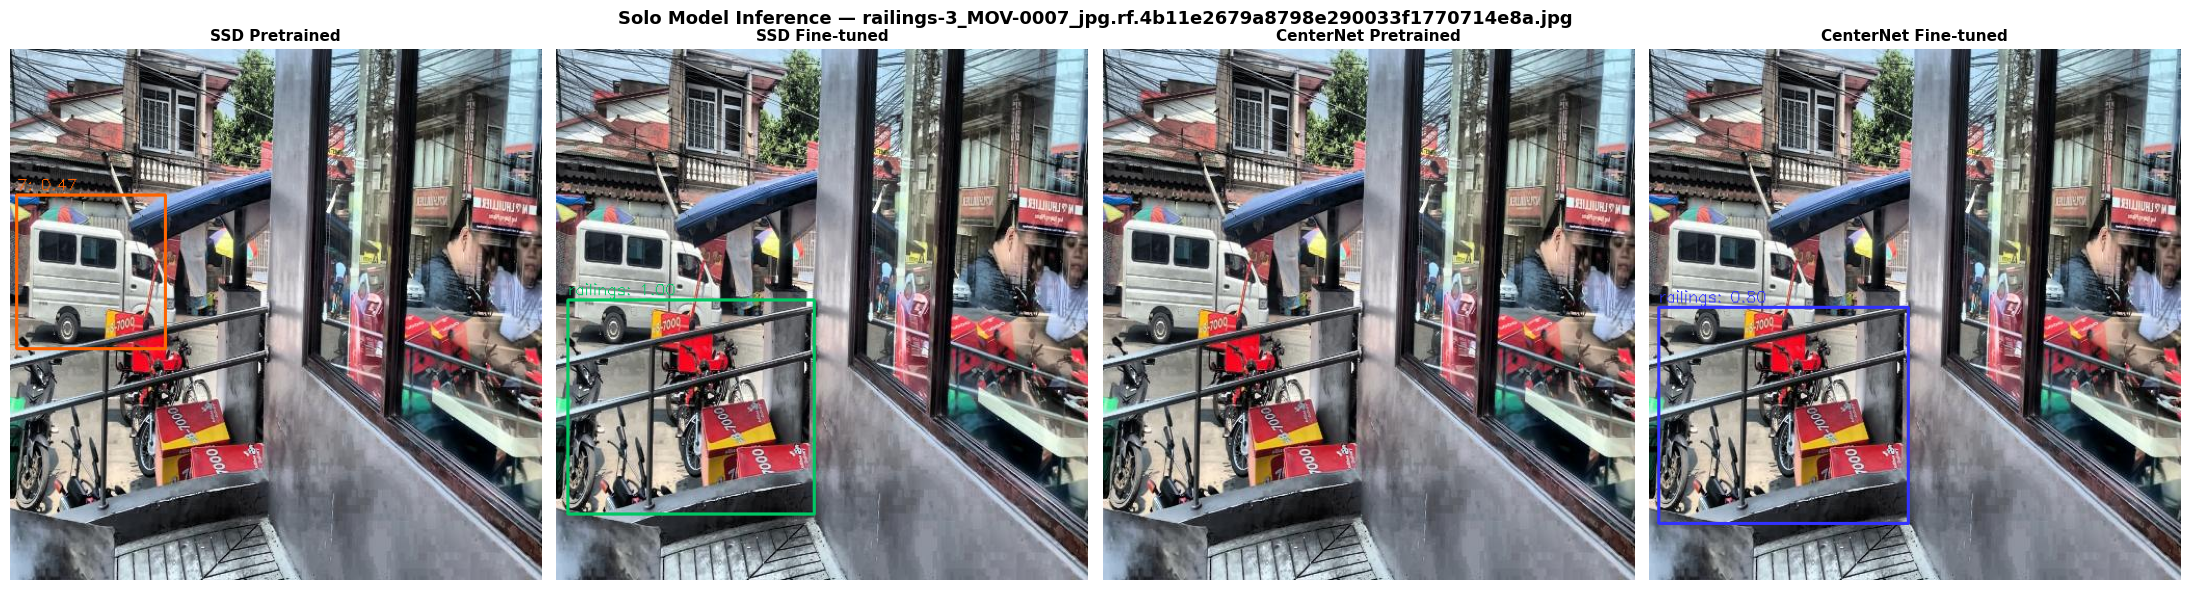

✅ Saved → /content/drive/MyDrive/thesis/benchmarks/charts/solo_inference_comparison.png

YOLOv8m Fine-tuned — detections above 0.3: 1
  railings: 0.959


In [ ]:
import torch, cv2, numpy as np
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — change these to test different images
# ══════════════════════════════════════════════════════════════════════════════

shutil.copytree(custom_test_images, '/content/test_images_local', dirs_exist_ok=True)

custom_img_list = [
    os.path.join('/content/test_images_local', f)
    for f in os.listdir('/content/test_images_local')
    if f.lower().endswith(('.jpg', '.png'))
]

TEST_IMG_PATH = custom_img_list[0]   # or specify any path
CONF_THRESH   = 0.3
CLASS_NAMES   = ['barriers', 'foldout-signs', 'poles', 'railings', 'signs']

# ══════════════════════════════════════════════════════════════════════════════
# HELPER: draw boxes on image
# ══════════════════════════════════════════════════════════════════════════════
def draw_boxes(img, boxes, scores, labels, class_names, color, normalized=True):
    img_out = img.copy()
    h, w    = img_out.shape[:2]
    for box, score, lbl in zip(boxes, scores, labels):
        if score < CONF_THRESH:
            continue
        lbl_int = int(round(lbl))
        if normalized:
            x1 = int(box[0] * w); y1 = int(box[1] * h)
            x2 = int(box[2] * w); y2 = int(box[3] * h)
        else:
            x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
        cv2.rectangle(img_out, (x1, y1), (x2, y2), color, 2)
        label_str = f"{class_names[lbl_int] if 0 <= lbl_int < len(class_names) else lbl_int}: {score:.2f}"
        cv2.putText(img_out, label_str, (x1, max(y1-5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img_out

# ══════════════════════════════════════════════════════════════════════════════
# LOAD IMAGE
# ══════════════════════════════════════════════════════════════════════════════
img_bgr     = cv2.imread(TEST_IMG_PATH)
img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_bgr, (TARGET_SIZE, TARGET_SIZE))
img_tensor  = (torch.from_numpy(img_resized / 255.)
                   .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

# ══════════════════════════════════════════════════════════════════════════════
# 1. SSD SOLO — pretrained
# ══════════════════════════════════════════════════════════════════════════════
ssd_model.eval()
with torch.no_grad():
    out_ssd_pre = ssd_model(img_tensor)[0]

boxes_ssd_pre  = out_ssd_pre['boxes'].cpu().numpy() / TARGET_SIZE
scores_ssd_pre = out_ssd_pre['scores'].cpu().numpy()
labels_ssd_pre = (out_ssd_pre['labels'].cpu().numpy() - 1)   # 0-indexed

# Filter by score
mask = scores_ssd_pre >= CONF_THRESH
print(f"SSD Pretrained   — detections above {CONF_THRESH}: {mask.sum()}")
print(f"  labels: {labels_ssd_pre[mask]}  scores: {scores_ssd_pre[mask].round(3)}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. SSD SOLO — fine-tuned
# ══════════════════════════════════════════════════════════════════════════════
ssd_ft.eval()
with torch.no_grad():
    out_ssd_ft = ssd_ft(img_tensor)[0]

boxes_ssd_ft  = out_ssd_ft['boxes'].cpu().numpy() / TARGET_SIZE
scores_ssd_ft = out_ssd_ft['scores'].cpu().numpy()
labels_ssd_ft = (out_ssd_ft['labels'].cpu().numpy() - 1)   # 0-indexed

mask_ft = scores_ssd_ft >= CONF_THRESH
print(f"\nSSD Fine-tuned   — detections above {CONF_THRESH}: {mask_ft.sum()}")
if mask_ft.sum() > 0:
    for lbl, scr in zip(labels_ssd_ft[mask_ft], scores_ssd_ft[mask_ft]):
        name = CLASS_NAMES[lbl] if 0 <= lbl < len(CLASS_NAMES) else f"cls_{lbl}"
        print(f"  {name}: {scr:.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. CENTERNET SOLO — pretrained
# ══════════════════════════════════════════════════════════════════════════════
center_model.eval()
with torch.no_grad():
    out_cn_pre = center_model(img_tensor)[-1]

boxes_cn_pre, scores_cn_pre, labels_cn_pre = decode_centernet(
    out_cn_pre, TARGET_SIZE, conf_thresh=CONF_THRESH
)
print(f"\nCenterNet Pretrained — detections above {CONF_THRESH}: {len(scores_cn_pre)}")
for lbl, scr in zip(labels_cn_pre, scores_cn_pre):
    print(f"  cls_{lbl}: {scr:.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. CENTERNET SOLO — fine-tuned
# ══════════════════════════════════════════════════════════════════════════════
center_ft.eval()
with torch.no_grad():
    out_cn_ft = center_ft(img_tensor)[-1]

boxes_cn_ft, scores_cn_ft, labels_cn_ft = decode_centernet(
    out_cn_ft, TARGET_SIZE, conf_thresh=CONF_THRESH
)
print(f"\nCenterNet Fine-tuned — detections above {CONF_THRESH}: {len(scores_cn_ft)}")
if len(scores_cn_ft) > 0:
    for lbl, scr in zip(labels_cn_ft, scores_cn_ft):
        name = CLASS_NAMES[lbl] if 0 <= lbl < len(CLASS_NAMES) else f"cls_{lbl}"
        print(f"  {name}: {scr:.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# 5. VISUALIZE ALL 4 SIDE BY SIDE
# ══════════════════════════════════════════════════════════════════════════════
img_display = cv2.cvtColor(cv2.resize(img_bgr, (TARGET_SIZE, TARGET_SIZE)),
                           cv2.COLOR_BGR2RGB)

vis_ssd_pre = draw_boxes(img_display,
    boxes_ssd_pre[mask], scores_ssd_pre[mask], labels_ssd_pre[mask],
    CLASS_NAMES, color=(255, 100, 0))

vis_ssd_ft  = draw_boxes(img_display,
    boxes_ssd_ft[mask_ft], scores_ssd_ft[mask_ft], labels_ssd_ft[mask_ft],
    CLASS_NAMES, color=(0, 200, 100))

vis_cn_pre  = draw_boxes(img_display,
    boxes_cn_pre, scores_cn_pre, labels_cn_pre,
    CLASS_NAMES, color=(255, 50, 50))

vis_cn_ft   = draw_boxes(img_display,
    boxes_cn_ft, scores_cn_ft, labels_cn_ft,
    CLASS_NAMES, color=(50, 50, 255))

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
titles = ['SSD Pretrained', 'SSD Fine-tuned',
          'CenterNet Pretrained', 'CenterNet Fine-tuned']
imgs   = [vis_ssd_pre, vis_ssd_ft, vis_cn_pre, vis_cn_ft]

for ax, title, im in zip(axes, titles, imgs):
    ax.imshow(im)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle(f"Solo Model Inference — {Path(TEST_IMG_PATH).name}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
fname = f"{SAVEDIR}/solo_inference_comparison.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {fname}")

# ══════════════════════════════════════════════════════════════════════════════
# 6. ALSO RUN YOLO FOR REFERENCE
# ══════════════════════════════════════════════════════════════════════════════
yolo_result = yolo_model.predict(
    TEST_IMG_PATH, imgsz=TARGET_SIZE, conf=CONF_THRESH, verbose=False
)[0]
print(f"\nYOLOv8m Fine-tuned — detections above {CONF_THRESH}: {len(yolo_result.boxes)}")
for box in yolo_result.boxes:
    cls  = int(box.cls)
    conf = float(box.conf)
    print(f"  {CLASS_NAMES[cls]}: {conf:.3f}")

In [ ]:
from tqdm import tqdm
import numpy as np
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ── Per-model solo mAP on full custom test set ─────────────────────────────
# We already have coco_gt_custom and the fixed JSON from Cell 4/5
# Just need to collect detections from each model separately

coco_gt_custom = COCO(custom_coco_json)

def compute_fnr_from_cocoeval(coco_eval_obj):
    """Extract TP/FN from completed COCOeval at IoU=0.50."""
    tp, fn = 0, 0
    for ev in coco_eval_obj.evalImgs:
        if ev is None:
            continue
        gt_ignore  = ev['gtIgnore']
        dt_matches = ev['dtMatches']
        if len(dt_matches) == 0:
            valid_gt_count = sum(1 for ig in gt_ignore if not ig)
            fn += valid_gt_count
            continue
        matched_gt_ids = set(m for m in dt_matches[0] if m > 0)
        for idx, ig in enumerate(gt_ignore):
            if ig:
                continue
            gt_id = ev['gtIds'][idx]
            if gt_id in matched_gt_ids:
                tp += 1
            else:
                fn += 1
    return round(fn / (fn + tp), 4) if (fn + tp) > 0 else 1.0

def run_solo_eval(model_fn, decode_fn, img_dir, coco_gt,
                  conf_thresh=0.3, label=""):
    """
    Runs a single model through the full test set and computes mAP@50 + FNR.
    model_fn: callable that takes img_tensor → raw output
    decode_fn: callable that takes raw output → (boxes_norm, scores, labels_0indexed)
    """
    img_ids = coco_gt.getImgIds()
    results = []

    for img_id in tqdm(img_ids, desc=f"Solo eval [{label}]"):
        info     = coco_gt.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, info['file_name'])
        w_orig, h_orig = info['width'], info['height']

        img_bgr    = cv2.imread(img_path)
        if img_bgr is None: continue
        img_resized = cv2.resize(img_bgr, (TARGET_SIZE, TARGET_SIZE))
        img_tensor  = (torch.from_numpy(img_resized / 255.)
                           .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

        with torch.no_grad():
            raw = model_fn(img_tensor)

        boxes, scores, labels = decode_fn(raw)

        for box, score, lbl in zip(boxes, scores, labels):
            if score < conf_thresh: continue
            lbl_int    = int(round(lbl))
            target_lbl = max(1, min(5, lbl_int + 1))  # shift 0-idx → 1-idx
            x1, y1, x2, y2 = box
            results.append({
                'image_id':    img_id,
                'category_id': target_lbl,
                'bbox': [x1*w_orig, y1*h_orig,
                         (x2-x1)*w_orig, (y2-y1)*h_orig],
                'score': float(score),
            })

    if not results:
        print(f"  ⚠️  [{label}] No detections above threshold.")
        return {'mAP50': 0.0, 'FNR': 1.0}

    coco_dt   = coco_gt.loadRes(results)
    ce        = COCOeval(coco_gt, coco_dt, 'bbox')
    ce.params.iouThrs = np.array([0.50])
    ce.evaluate(); ce.accumulate(); ce.summarize()
    map50 = round(float(ce.stats[0]), 4)
    fnr   = compute_fnr_from_cocoeval(ce)
    return {'mAP50': map50, 'FNR': fnr}

# ── Decode wrappers ────────────────────────────────────────────────────────
def ssd_ft_model_fn(img_tensor):
    return ssd_ft(img_tensor)[0]

def ssd_ft_decode_fn(raw):
    boxes  = (raw['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
    scores = raw['scores'].cpu().numpy().tolist()
    labels = (raw['labels'].cpu().numpy() - 1).tolist()  # 1-idx → 0-idx
    return boxes, scores, labels

def center_ft_model_fn(img_tensor):
    return center_ft(img_tensor)[-1]

def center_ft_decode_fn(raw):
    boxes, scores, labels = decode_centernet(raw, TARGET_SIZE, conf_thresh=0.3)
    return boxes.tolist(), scores.tolist(), labels.tolist()

# ── Run ────────────────────────────────────────────────────────────────────
print("Running solo evaluations on full custom test set...")
res_ssd    = run_solo_eval(ssd_ft_model_fn,    ssd_ft_decode_fn,
                           custom_coco_images,  coco_gt_custom,
                           label="SSD Fine-tuned")
res_center = run_solo_eval(center_ft_model_fn, center_ft_decode_fn,
                           custom_coco_images,  coco_gt_custom,
                           label="CenterNet Fine-tuned")

print(f"\n{'Model':<30} {'mAP@50':>8} {'FNR':>8}")
print("-" * 48)
print(f"{'YOLOv8m (fine-tuned)':<30} {'0.9364':>8} {'0.0942':>8}")
print(f"{'SSD (fine-tuned solo)':<30} {res_ssd['mAP50']:>8} {res_ssd['FNR']:>8}")
print(f"{'CenterNet (fine-tuned solo)':<30} {res_center['mAP50']:>8} {res_center['FNR']:>8}")
print(f"{'Hybrid WBF (post FT)':<30} {'0.1195':>8} {'0.7677':>8}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Running solo evaluations on full custom test set...


Solo eval [SSD Fine-tuned]: 100%|██████████| 467/467 [00:12<00:00, 37.48it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.12s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.671
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.671
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.252
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.437
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.771
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.565
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.709
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.709
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

Solo eval [CenterNet Fine-tuned]: 100%|██████████| 467/467 [00:08<00:00, 55.91it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.15s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.570
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.570
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.451
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.620
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.520
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.658
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.658
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

In [ ]:
import torch, os, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
from pathlib import Path
import cv2

CENTER_SAVE_V2 = "/content/drive/MyDrive/thesis/models/finetuned/mobilenet_centernet_v2.pth"
os.makedirs(os.path.dirname(CENTER_SAVE), exist_ok=True)
NUM_CLASSES_CN = 5   # CenterNet does NOT use a background class

# ── 1. REPLACE HEATMAP HEAD (80 → 5 classes) ──────────────────────────────────
# Load the original pretrained model from Cell 1
center_ft = MobileNetV3CenterNet(num_classes=NUM_CLASSES_CN, pretrained=True).to(DEVICE)
print("✅ MobileNetV3CenterNet initialized with ImageNet pretrained backbone.")

# Run this before replacing the hm head to inspect all head input sizes
dummy = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE).to(DEVICE)
with torch.no_grad():
    out = center_ft(dummy)[-1]
print(f"hm: {out['hm'].shape}  wh: {out['wh'].shape}  reg: {out['reg'].shape}")

# Replace only the heatmap head — wh and reg heads stay the same
center_ft.hm = nn.Sequential(
    nn.Conv2d(256, 64, kernel_size=3, padding=1),  # 256 input channels
    nn.ReLU(inplace=True),
    nn.Conv2d(64, NUM_CLASSES_CN, kernel_size=1),
).to(DEVICE)

# Initialize heatmap head with bias = -2.19 (standard CenterNet init, suppresses
# background activations at start of training)
for layer in center_ft.hm:
    if isinstance(layer, nn.Conv2d):
        nn.init.normal_(layer.weight, std=0.001)
        nn.init.constant_(layer.bias, 0)
# Set the final layer bias specifically
nn.init.constant_(center_ft.hm[-1].bias, -2.19)

print("✅ CenterNet head replaced: 80 → 5 classes")

✅ MobileNetV3CenterNet initialized with ImageNet pretrained backbone.
hm: torch.Size([1, 5, 64, 64])  wh: torch.Size([1, 2, 64, 64])  reg: torch.Size([1, 2, 64, 64])
✅ CenterNet head replaced: 80 → 5 classes


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL EVALUATION WITH BEST TEMPERATURES — on test set
# ══════════════════════════════════════════════════════════════════════════════
print(f"\nEvaluating best temperatures on test set...")
print(f"T_ssd={best_T_ssd}  T_center={best_T_cen}")

test_img_ids = coco_gt_custom.getImgIds()
map50_final  = run_wbf_with_temperature(
    custom_coco_images, coco_gt_custom, test_img_ids,
    best_T_ssd, best_T_cen
)

print(f"\n{'Model':<35} {'mAP@50':>8} {'Note':>20}")
print("-" * 65)
print(f"{'YOLOv8m (fine-tuned)':<35} {'0.9364':>8}")
print(f"{'SSD solo (fine-tuned)':<35} {'0.6709':>8}")
print(f"{'CenterNet solo (fine-tuned)':<35} {'0.6852':>8}")
print(f"{'Hybrid WBF (no calibration)':<35} {'0.1195':>8} {'← before':>20}")
print(f"{'Hybrid WBF (T-scaled)':<35} {map50_final:>8} {'← after':>20}")


Evaluating best temperatures on test set...
T_ssd=0.5  T_center=1.5
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.17s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.121
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.121
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.131
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.191
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.229
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.22

In [ ]:
def run_hybrid_inference (img_path, conf_thresh=0.1):
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, 0

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_tensor  = (torch.from_numpy(img_resized / 255.)
                       .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    torch.cuda.synchronize()
    t1 = time.time()

    with torch.no_grad():
        out_ssd    = ssd_ft(img_tensor)[0]
        out_center = center_ft(img_tensor)[-1]

    torch.cuda.synchronize()
    latency = time.time() - t1

    # ── SSD outputs
    boxes_ssd  = (out_ssd['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
    scores_ssd = out_ssd['scores'].cpu().numpy().tolist()
    labels_ssd = (out_ssd['labels'].cpu().numpy() - 1).tolist()

    # ── CenterNet outputs
    boxes_cen, scores_cen, labels_cen = decode_centernet(
        out_center, TARGET_SIZE, conf_thresh
    )
    boxes_cen  = boxes_cen.tolist()
    scores_cen = scores_cen.tolist()
    labels_cen = labels_cen.tolist()

    if not boxes_ssd and not boxes_cen:
        return [], [], [], latency

    # ── Track which model each box came from before fusion
    # Tag: 0 = SSD, 1 = CenterNet
    source_tags = [0] * len(boxes_ssd) + [1] * len(boxes_cen)

    all_boxes  = boxes_ssd  + boxes_cen
    all_scores = scores_ssd + scores_cen
    all_labels = labels_ssd + labels_cen

    # ── WBF on boxes and scores only
    # Pass unified labels so WBF groups by class correctly,
    # but we override final labels using highest-score source
    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
        [boxes_ssd,  boxes_cen],
        [scores_ssd, scores_cen],
        [labels_ssd, labels_cen],
        weights=[1, 2],
        iou_thr=0.45,
        skip_box_thr=conf_thresh,
    )

    # ── Override fused labels: for each fused box, find the highest-score
    # contributing detection and use its label directly (no averaging)
    final_labels = []
    for fbox in fused_boxes:
        best_iou   = 0.0
        best_label = 0
        best_score = 0.0
        fx1, fy1, fx2, fy2 = fbox

        for box, score, lbl in zip(all_boxes, all_scores, all_labels):
            bx1, by1, bx2, by2 = box
            # Compute IoU
            ix1 = max(fx1, bx1); iy1 = max(fy1, by1)
            ix2 = min(fx2, bx2); iy2 = min(fy2, by2)
            inter = max(0, ix2-ix1) * max(0, iy2-iy1)
            union = ((fx2-fx1)*(fy2-fy1) +
                     (bx2-bx1)*(by2-by1) - inter)
            iou   = inter / union if union > 0 else 0.0
            if iou > 0.3 and score > best_score:
                best_score = score
                best_label = lbl

        final_labels.append(best_label)

    return (fused_boxes.tolist(),
            fused_scores.tolist(),
            final_labels,
            latency)

In [ ]:
def run_hybrid_inference_wbf_tuned(img_path,
                                    iou_thr=0.25,      # lowered from 0.45
                                    skip_box_thr=0.05, # lowered from 0.1
                                    conf_thresh=0.1):
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, 0

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_tensor  = (torch.from_numpy(img_resized / 255.)
                       .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    torch.cuda.synchronize()
    t1 = time.time()

    with torch.no_grad():
        out_ssd    = ssd_ft(img_tensor)[0]
        out_center = center_ft(img_tensor)[-1]

    torch.cuda.synchronize()
    latency = time.time() - t1

    boxes_ssd  = (out_ssd['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
    scores_ssd = out_ssd['scores'].cpu().numpy().tolist()
    labels_ssd = (out_ssd['labels'].cpu().numpy() - 1).tolist()

    boxes_cen, scores_cen, labels_cen = decode_centernet(
        out_center, TARGET_SIZE, conf_thresh
    )
    boxes_cen  = boxes_cen.tolist()
    scores_cen = scores_cen.tolist()
    labels_cen = labels_cen.tolist()

    if not boxes_ssd and not boxes_cen:
        return [], [], [], latency

    boxes, scores, labels = weighted_boxes_fusion(
        [boxes_ssd,  boxes_cen],
        [scores_ssd, scores_cen],
        [labels_ssd, labels_cen],
        weights=[1, 2],
        iou_thr=iou_thr,
        skip_box_thr=skip_box_thr,
    )
    return boxes.tolist(), scores.tolist(), labels.tolist(), latency

# ── Quick grid search on WBF hyperparameters ───────────────────────────────
import itertools

IOU_GRID  = [0.25, 0.35, 0.45]   # original was 0.45
SKIP_GRID = [0.05, 0.07, 0.10]   # original was 0.10

print("WBF hyperparameter grid search...")
print(f"{'iou_thr':>10} {'skip_thr':>10} {'mAP@50':>10}")
print("-" * 35)

best_wbf_map = 0.0
best_iou     = 0.45
best_skip    = 0.10

for iou_thr, skip_thr in itertools.product(IOU_GRID, SKIP_GRID):
    # Patch inference function temporarily
    results = []
    for img_id in coco_gt_custom.getImgIds():
        info     = coco_gt_custom.loadImgs(img_id)[0]
        img_path = os.path.join(custom_coco_images, info['file_name'])
        w_orig, h_orig = info['width'], info['height']

        boxes, scores, labels_out, _ = run_hybrid_inference_wbf_tuned(
            img_path, iou_thr=iou_thr, skip_box_thr=skip_thr
        )
        if not boxes: continue

        for box, score, lbl in zip(boxes, scores, labels_out):
            lbl_int    = int(round(lbl))
            target_lbl = max(1, min(5, lbl_int if lbl_int >= 1 else lbl_int + 1))
            x1, y1, x2, y2 = box
            results.append({
                'image_id':    img_id,
                'category_id': target_lbl,
                'bbox': [x1*w_orig, y1*h_orig,
                         (x2-x1)*w_orig, (y2-y1)*h_orig],
                'score': float(score),
            })

    if not results:
        print(f"{iou_thr:>10} {skip_thr:>10} {'0.0000':>10}")
        continue

    coco_dt = coco_gt_custom.loadRes(results)
    ce      = COCOeval(coco_gt_custom, coco_dt, 'bbox')
    ce.params.iouThrs = np.array([0.50])
    ce.evaluate(); ce.accumulate(); ce.summarize()
    map50 = round(float(ce.stats[0]), 4)
    print(f"{iou_thr:>10} {skip_thr:>10} {map50:>10}")

    if map50 > best_wbf_map:
        best_wbf_map = map50
        best_iou     = iou_thr
        best_skip    = skip_thr

print(f"\nBest WBF settings: iou_thr={best_iou}  skip_thr={best_skip}  mAP={best_wbf_map}")

In [ ]:
from ensemble_boxes import non_maximum_weighted, soft_nms

def collect_raw_detections(img_path, conf_thresh=0.1):
    """
    Returns raw SSD and CenterNet detections for a single image
    without any fusion applied yet.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None, None, None, None, None, None

    img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    img_tensor  = (torch.from_numpy(img_resized / 255.)
                       .permute(2, 0, 1).float().unsqueeze(0).to(DEVICE))

    with torch.no_grad():
        out_ssd    = ssd_ft(img_tensor)[0]
        out_center = center_ft(img_tensor)[-1]

    boxes_ssd  = (out_ssd['boxes'].cpu().numpy() / TARGET_SIZE).tolist()
    scores_ssd = out_ssd['scores'].cpu().numpy().tolist()
    labels_ssd = (out_ssd['labels'].cpu().numpy() - 1).tolist()

    boxes_cen, scores_cen, labels_cen = decode_centernet(
        out_center, TARGET_SIZE, conf_thresh
    )
    return (boxes_ssd, scores_ssd, labels_ssd,
            boxes_cen.tolist(), scores_cen.tolist(), labels_cen.tolist())


def eval_fusion_method(fusion_name, fusion_fn,
                       img_dir, coco_gt, conf_thresh=0.1):
    """
    Evaluates a given fusion function on the full test set.
    fusion_fn signature: (boxes_list, scores_list, labels_list) → boxes, scores, labels
    """
    results = []
    img_ids = coco_gt.getImgIds()

    for img_id in tqdm(img_ids, desc=f"[{fusion_name}]"):
        info     = coco_gt.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, info['file_name'])
        w_orig, h_orig = info['width'], info['height']

        raw = collect_raw_detections(img_path, conf_thresh)
        if raw[0] is None: continue
        (boxes_ssd, scores_ssd, labels_ssd,
         boxes_cen, scores_cen, labels_cen) = raw

        if not boxes_ssd and not boxes_cen: continue

        try:
            boxes, scores, labels_out = fusion_fn(
                [boxes_ssd,  boxes_cen],
                [scores_ssd, scores_cen],
                [labels_ssd, labels_cen],
            )
        except Exception as e:
            continue

        for box, score, lbl in zip(boxes, scores, labels_out):
            lbl_int    = int(round(lbl))
            target_lbl = max(1, min(5, lbl_int if lbl_int >= 1 else lbl_int + 1))
            x1, y1, x2, y2 = box
            results.append({
                'image_id':    img_id,
                'category_id': target_lbl,
                'bbox': [x1*w_orig, y1*h_orig,
                         (x2-x1)*w_orig, (y2-y1)*h_orig],
                'score': float(score),
            })

    if not results:
        return 0.0, 1.0

    coco_dt = coco_gt.loadRes(results)
    ce      = COCOeval(coco_gt, coco_dt, 'bbox')
    ce.params.iouThrs = np.array([0.50])
    ce.evaluate(); ce.accumulate(); ce.summarize()
    map50 = round(float(ce.stats[0]), 4)
    fnr   = compute_fnr_from_cocoeval(ce)
    return map50, fnr


# ── Define fusion methods ──────────────────────────────────────────────────

# 1. WBF original (baseline)
def fusion_wbf(boxes_list, scores_list, labels_list):
    return weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        weights=[1, 2], iou_thr=0.45, skip_box_thr=0.1
    )

# 2. Non-Maximum Weighted (NMW) — softer suppression than WBF
# All boxes contribute to final position weighted by score,
# none are hard-suppressed
def fusion_nmw(boxes_list, scores_list, labels_list):
    return non_maximum_weighted(
        boxes_list, scores_list, labels_list,
        weights=[1, 2], iou_thr=0.45, skip_box_thr=0.1
    )

# 3. Soft-NMS — decays scores of overlapping boxes instead of removing them
# Better at retaining nearby detections of the same class
def fusion_softnms(boxes_list, scores_list, labels_list):
    # soft_nms requires flat inputs — concatenate both model outputs first
    all_boxes  = boxes_list[0]  + boxes_list[1]
    all_scores = scores_list[0] + scores_list[1]
    all_labels = labels_list[0] + labels_list[1]
    if not all_boxes:
        return np.array([]), np.array([]), np.array([])
    boxes_out, scores_out, labels_out = soft_nms(
        [all_boxes], [all_scores], [all_labels],
        weights=[1], iou_thr=0.45, skip_box_thr=0.1, sigma=0.5
    )
    return boxes_out, scores_out, labels_out

# 4. Union (no suppression) — keep ALL detections from both models
# If WBF suppression is the problem, this should show the ceiling
def fusion_union(boxes_list, scores_list, labels_list):
    all_boxes  = np.array(boxes_list[0]  + boxes_list[1])
    all_scores = np.array(scores_list[0] + scores_list[1])
    all_labels = np.array(labels_list[0] + labels_list[1])
    # Filter by confidence only, no suppression at all
    mask = all_scores >= 0.1
    return all_boxes[mask], all_scores[mask], all_labels[mask]

# ── Run all fusion methods ─────────────────────────────────────────────────
fusion_methods = {
    'WBF (original)':   fusion_wbf,
    'NMW':              fusion_nmw,
    'Soft-NMS':         fusion_softnms,
    'Union (no NMS)':   fusion_union,
}

print("\nEvaluating alternative fusion methods on custom test set...")
print(f"\n{'Method':<25} {'mAP@50':>8} {'FNR':>8}")
print("-" * 45)

fusion_results = {}
for name, fn in fusion_methods.items():
    map50, fnr = eval_fusion_method(
        name, fn, custom_coco_images, coco_gt_custom
    )
    fusion_results[name] = {'mAP50': map50, 'FNR': fnr}
    print(f"{name:<25} {map50:>8} {fnr:>8}")

# Reference numbers
print("-" * 45)
print(f"{'SSD solo':<25} {'0.6709':>8} {'0.2911':>8}")
print(f"{'CenterNet solo':<25} {'0.6852':>8} {'0.2804':>8}")
print(f"{'YOLOv8m':<25} {'0.9364':>8} {'0.0942':>8}")

# Save
fusion_df = pd.DataFrame([
    {'Method': k, 'mAP50': v['mAP50'], 'FNR': v['FNR']}
    for k, v in fusion_results.items()
])

SAVEDIR = "/content/drive/MyDrive/thesis/benchmarks/charts"
import os; os.makedirs(SAVEDIR, exist_ok=True)

fusion_df.to_csv(f"{SAVEDIR}/fusion_method_comparison.csv", index=False)
print(f"\n✅ Saved → {SAVEDIR}/fusion_method_comparison.csv")


Evaluating alternative fusion methods on custom test set...

Method                      mAP@50      FNR
---------------------------------------------


[WBF (original)]: 100%|██████████| 467/467 [00:17<00:00, 27.12it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.24s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.152
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.152
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.121
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.163
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.244
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

[NMW]: 100%|██████████| 467/467 [00:18<00:00, 25.55it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.50s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.154
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.154
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.115
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.166
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.243
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1

[Soft-NMS]: 100%|██████████| 467/467 [00:17<00:00, 27.06it/s]


Soft-NMS                       0.0      1.0


[Union (no NMS)]: 100%|██████████| 467/467 [00:17<00:00, 26.95it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.25s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.134
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.134
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.091
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.151
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.241
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.305
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets=1